In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
kdd_train= pd.read_csv("kdd_train.csv")


In [3]:
kdd_test= pd.read_csv("kdd_test.csv")


In [4]:
kdd_train.shape

(125973, 45)

In [5]:
kdd_test.shape

(22544, 45)

### Attributes type-wise

In [6]:
basic_attr=['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment','urgent']
content_attr=['hot', 'num_failed_logins', 'logged_in', 'num_compromised',
       'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
       'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login']
time_attr=['count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate']
host_attr=['dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate']

### DATA CLEANSING

#### DUPLICATE VALUE TREATMENT

In [7]:
print(kdd_train.shape)
kdd_train=kdd_train.drop_duplicates(keep='first')
print(kdd_train.shape)


(125973, 45)
(125973, 45)


In [8]:
print(kdd_test.shape)
kdd_test=kdd_test.drop_duplicates(keep='first')
print(kdd_test.shape)


(22544, 45)
(22544, 45)


#### NO DUPLCATE ENTRIES FOUND 

#### MISSING VALUE TREATMENT

In [9]:
kdd_train.isnull().mean().sum()

0.0

In [10]:
kdd_test.isnull().mean().sum()

0.0

#### No missing values in Train and Test Data

#### OUTLIER TREATMENT

#### Function to detect outliers using Inter Quartile Value (IQR) Method

In [11]:
def detect_iqr_outlier(dataset):

#Fist sorting the dataset
#Finding first quartile and third quartile
#Find the IQR which is the difference between third and first quartile
#Find lower and upper bound
    outliers=[]
    sorted(dataset)
    q1=dataset.quantile(0.25)
    q3= dataset.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 -(1.5 * iqr) 
    upper_bound = q3 +(1.5 * iqr)
    for y in dataset:
         
        if (lower_bound > y or y > upper_bound):
            outliers.append(y)
    return outliers


#### Function to detect outliers using z-score method 

In [12]:
def detect_outlier(data_1):
    outliers=[]
    threshold=1
    #data_1=combined_df[col_1]
    mean_1 = np.mean(data_1)
    std_1 =np.std(data_1)
    
    
    for y in data_1:
        z_score= (y - mean_1)/std_1 
        if np.abs(z_score) > threshold:
            outliers.append(y)
    return outliers

#### Function to plot box plots for identifying outliers 

In [13]:
def plot_box(df,col):
    plt.figure(figsize=(30,9))
    df[col].boxplot()
    plt.title("Box plot for outliers", fontsize=20)
    plt.show()

In [14]:
kdd_train[basic_attr].describe(percentiles = [0.25,0.50,0.75,0.85,0.90,0.95,0.99,1]).transpose()

,count,mean,std,min,25%,50%,75%,85%,90%,95%,99%,100%,max
duration,125973.0,287.144650,2.604515e+03,0.0,0.0,0.0,0.0,0.0,0.0,4.0,9590.56,4.290800e+04,4.290800e+04
src_bytes,125973.0,45566.743000,5.870331e+06,0.0,0.0,44.0,276.0,337.0,848.0,1480.0,54540.00,1.379964e+09,1.379964e+09
dst_bytes,125973.0,19779.114421,4.021269e+06,0.0,0.0,0.0,516.0,1908.0,3375.8,8314.0,25519.00,1.309937e+09,1.309937e+09
land,125973.0,0.000198,1.408607e-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,1.000000e+00,1.000000e+00
wrong_fragment,125973.0,0.022687,2.535300e-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,3.000000e+00,3.000000e+00
urgent,125973.0,0.000111,1.436603e-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,3.000000e+00,3.000000e+00


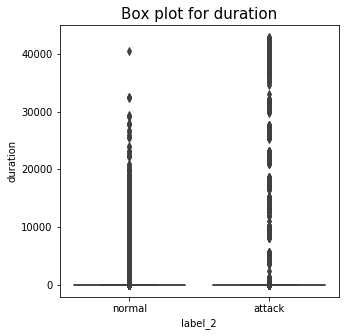

In [15]:
plt.figure(figsize=(5,5))
sns.boxplot(y='duration',x='label_2', data=kdd_train)
plt.title("Box plot for duration", fontsize=15)
plt.show()


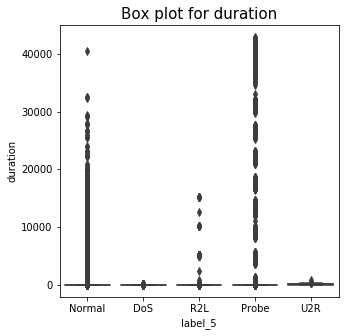

In [16]:
plt.figure(figsize=(5,5))
sns.boxplot(y='duration',x='label_5', data=kdd_train)
plt.title("Box plot for duration", fontsize=15)
plt.show()


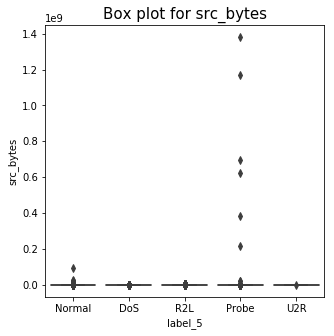

In [17]:
plt.figure(figsize=(5,5))
sns.boxplot(y='src_bytes',x='label_5', data=kdd_train)
plt.title("Box plot for src_bytes", fontsize=15)
plt.show()


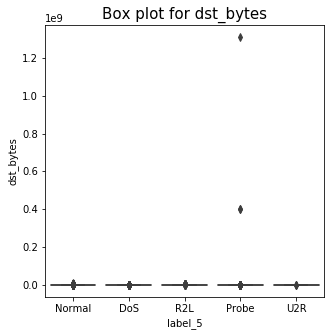

In [18]:
plt.figure(figsize=(5,5))
sns.boxplot(y='dst_bytes',x='label_5', data=kdd_train)
plt.title("Box plot for dst_bytes", fontsize=15)
plt.show()


In [19]:
print(len(detect_outlier(kdd_train['duration'])))

2229


In [20]:
kdd_train[kdd_train['duration'] > kdd_train['duration'].quantile(0.99)].shape

(1260, 45)

In [21]:
y=kdd_train[kdd_train['duration'] > kdd_train['duration'].quantile(0.99)]
y['label_5'].value_counts()

Probe     816
Normal    422
R2L        22
Name: label_5, dtype: int64

In [22]:
y=kdd_train[kdd_train['src_bytes'] > kdd_train['src_bytes'].quantile(0.99)]
y['label_5'].value_counts()

Normal    520
R2L        60
Probe       8
Name: label_5, dtype: int64

In [23]:
y=kdd_train[kdd_train['dst_bytes'] > kdd_train['dst_bytes'].quantile(0.99)]
y['label_5'].value_counts()

Normal    1233
R2L         20
Probe        4
U2R          1
Name: label_5, dtype: int64

In [24]:
y=kdd_train[kdd_train['num_compromised'] > kdd_train['num_compromised'].quantile(0.99)]
y['label_5'].value_counts()

Normal    288
U2R        18
R2L         3
Probe       1
Name: label_5, dtype: int64

In [25]:
y=kdd_train[kdd_train['num_root'] > kdd_train['num_root'].quantile(0.99)]
y['label_5'].value_counts()

Normal    630
U2R        10
R2L         5
Probe       4
Name: label_5, dtype: int64

There are significant amount of data above 0.99 quantile.Hence cannot be considered as outlier

In [26]:
kdd_train[content_attr].describe(percentiles = [0.25,0.50,0.75,0.85,0.90,0.95,0.99,1]).transpose()

,count,mean,std,min,25%,50%,75%,85%,90%,95%,99%,100%,max
hot,125973.0,0.204409,2.149968,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,77.0,77.0
num_failed_logins,125973.0,0.001222,0.045239,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,5.0
logged_in,125973.0,0.395736,0.489010,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
num_compromised,125973.0,0.279250,23.942042,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,7479.0,7479.0
root_shell,125973.0,0.001342,0.036603,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
su_attempted,125973.0,0.001103,0.045154,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0
num_root,125973.0,0.302192,24.399618,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7468.0,7468.0
num_file_creations,125973.0,0.012669,0.483935,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,43.0,43.0
num_shells,125973.0,0.000413,0.022181,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0
num_access_files,125973.0,0.004096,0.099370,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,9.0


Text(0.5,1,'Box plot for num_compromised')

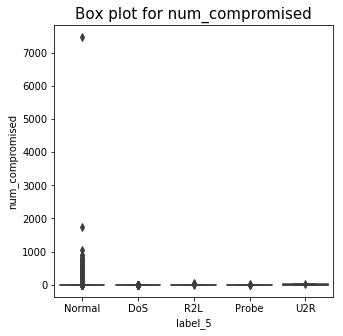

In [27]:
plt.figure(figsize=(5,5))
#plt.subplot(1,2,1)
sns.boxplot(y='num_compromised',x='label_5', data=kdd_train)
plt.title("Box plot for num_compromised", fontsize=15)

Text(0.5,1,'Box plot for num_root')

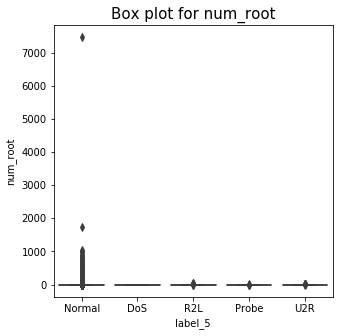

In [28]:
plt.figure(figsize=(5,5))
sns.boxplot(y='num_root',x='label_5', data=kdd_train)
plt.title("Box plot for num_root", fontsize=15)

In [29]:
print(len(detect_outlier(kdd_train['num_compromised'])))

69


In [30]:
kdd_train[kdd_train['num_compromised'] > kdd_train['num_compromised'].quantile(0.99)].shape

(310, 45)

In [31]:
print(len(detect_outlier(kdd_train['num_root'])))

70


In [32]:
kdd_train[kdd_train['num_root'] > kdd_train['num_compromised'].quantile(0.99)].shape

(376, 45)

#### There are significant amount of data above 0.99 quantile.Hence cannot be considered as outlier

In [33]:
kdd_train[time_attr].describe(percentiles = [0.25,0.50,0.75,0.85,0.90,0.95,0.99,1]).transpose()

,count,mean,std,min,25%,50%,75%,85%,90%,95%,99%,100%,max
count,125973.0,84.107555,114.508607,0.0,2.00,14.0,143.00,229.00,256.00,286.00,511.0,511.0,511.0
srv_count,125973.0,27.737888,72.635840,0.0,2.00,8.0,18.00,24.00,40.00,158.00,492.0,511.0,511.0
serror_rate,125973.0,0.284485,0.446456,0.0,0.00,0.0,1.00,1.00,1.00,1.00,1.0,1.0,1.0
srv_serror_rate,125973.0,0.282485,0.447022,0.0,0.00,0.0,1.00,1.00,1.00,1.00,1.0,1.0,1.0
rerror_rate,125973.0,0.119958,0.320436,0.0,0.00,0.0,0.00,0.00,1.00,1.00,1.0,1.0,1.0
srv_rerror_rate,125973.0,0.121183,0.323647,0.0,0.00,0.0,0.00,0.00,1.00,1.00,1.0,1.0,1.0
same_srv_rate,125973.0,0.660928,0.439623,0.0,0.09,1.0,1.00,1.00,1.00,1.00,1.0,1.0,1.0
diff_srv_rate,125973.0,0.063053,0.180314,0.0,0.00,0.0,0.06,0.07,0.07,0.29,1.0,1.0,1.0
srv_diff_host_rate,125973.0,0.097322,0.259830,0.0,0.00,0.0,0.00,0.14,0.31,1.00,1.0,1.0,1.0


In [34]:
kdd_train[host_attr].describe(percentiles = [0.25,0.50,0.75,0.85,0.90,0.95,0.99,1]).transpose()

,count,mean,std,min,25%,50%,75%,85%,90%,95%,99%,100%,max
dst_host_count,125973.0,182.148945,99.206213,0.0,82.00,255.00,255.00,255.00,255.00,255.00,255.00,255.0,255.0
dst_host_srv_count,125973.0,115.653005,110.702741,0.0,10.00,63.00,255.00,255.00,255.00,255.00,255.00,255.0,255.0
dst_host_same_srv_rate,125973.0,0.521242,0.448949,0.0,0.05,0.51,1.00,1.00,1.00,1.00,1.00,1.0,1.0
dst_host_diff_srv_rate,125973.0,0.082951,0.188922,0.0,0.00,0.02,0.07,0.08,0.10,0.56,1.00,1.0,1.0
dst_host_same_src_port_rate,125973.0,0.148379,0.308997,0.0,0.00,0.00,0.06,0.35,0.84,1.00,1.00,1.0,1.0
dst_host_srv_diff_host_rate,125973.0,0.032542,0.112564,0.0,0.00,0.00,0.02,0.04,0.05,0.18,0.52,1.0,1.0
dst_host_serror_rate,125973.0,0.284452,0.444784,0.0,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.0,1.0
dst_host_srv_serror_rate,125973.0,0.278485,0.445669,0.0,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.0,1.0
dst_host_rerror_rate,125973.0,0.118832,0.306557,0.0,0.00,0.00,0.00,0.04,0.84,1.00,1.00,1.0,1.0
dst_host_srv_rerror_rate,125973.0,0.120240,0.319459,0.0,0.00,0.00,0.00,0.01,1.00,1.00,1.00,1.0,1.0


## KDD TRAIN EDA

In [35]:
kdd_train.select_dtypes("object").columns

Index(['protocol_type', 'service', 'flag', 'attack', 'label_5', 'label_2'], dtype='object')

In [36]:
categ_columns=['protocol_type', 'service', 'flag']


In [37]:
kdd_train['protocol_type'].value_counts()


tcp     102689
udp      14993
icmp      8291
Name: protocol_type, dtype: int64

In [38]:
kdd_train['service'].value_counts().head()

http        40338
private     21853
domain_u     9043
smtp         7313
ftp_data     6860
Name: service, dtype: int64

In [39]:
kdd_train['flag'].value_counts()

SF        74945
S0        34851
REJ       11233
RSTR       2421
RSTO       1562
S1          365
SH          271
S2          127
RSTOS0      103
S3           49
OTH          46
Name: flag, dtype: int64

In [40]:
kdd_train.select_dtypes([np.number]).columns

Index(['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment',
       'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised',
       'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
       'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'last_flag'],
      dtype='object')

In [41]:
len(kdd_train.select_dtypes([np.number]).columns)

39

In [42]:
binary_cols=['land','logged_in','root_shell', 'su_attempted','is_host_login','is_guest_login']


### BASIC ATTRIBUTES

    duration 
    protocol_type
    service
    flag
    src_bytes
    dst_bytes
    land
    wrong_fragment
    urgent


In [43]:
kdd_train[basic_attr].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
duration,125973.0,287.144650,2.604515e+03,0.0,0.0,0.0,0.0,4.290800e+04
src_bytes,125973.0,45566.743000,5.870331e+06,0.0,0.0,44.0,276.0,1.379964e+09
dst_bytes,125973.0,19779.114421,4.021269e+06,0.0,0.0,0.0,516.0,1.309937e+09
land,125973.0,0.000198,1.408607e-02,0.0,0.0,0.0,0.0,1.000000e+00
wrong_fragment,125973.0,0.022687,2.535300e-01,0.0,0.0,0.0,0.0,3.000000e+00
urgent,125973.0,0.000111,1.436603e-02,0.0,0.0,0.0,0.0,3.000000e+00


In [44]:
print(pd.crosstab(kdd_train['protocol_type'], kdd_train['label_2']),"\n")
print(pd.crosstab(kdd_train['protocol_type'], kdd_train['label_5']))

label_2        attack  normal
protocol_type                
icmp             6982    1309
tcp             49089   53600
udp              2559   12434 

label_5          DoS  Normal  Probe  R2L  U2R
protocol_type                                
icmp            2847    1309   4135    0    0
tcp            42188   53600   5857  995   49
udp              892   12434   1664    0    3


In [45]:
print(pd.crosstab(kdd_train['flag'], kdd_train['label_2']),"\n")
print(pd.crosstab(kdd_train['flag'], kdd_train['label_5']))

label_2  attack  normal
flag                   
OTH          35      11
REJ        8540    2693
RSTO       1343     219
RSTOS0      103       0
RSTR       2275     146
S0        34497     354
S1            4     361
S2            8     119
S3            4      45
SF        11552   63393
SH          269       2 

label_5    DoS  Normal  Probe  R2L  U2R
flag                                   
OTH          0      11     35    0    0
REJ       5671    2693   2869    0    0
RSTO      1216     219     80   46    1
RSTOS0       0       0    103    0    0
RSTR        90     146   2180    5    0
S0       34344     354    153    0    0
S1           2     361      1    1    0
S2           5     119      2    1    0
S3           0      45      1    3    0
SF        4599   63393   5967  935   51
SH           0       2    265    4    0


In [46]:
print(pd.crosstab(kdd_train['service'], kdd_train['label_2']),"\n")
print(pd.crosstab(kdd_train['service'], kdd_train['label_5']))

label_2     attack  normal
service                   
IRC              1     186
X11              6      67
Z39_50         862       0
aol              2       0
auth           719     236
bgp            710       0
courier        734       0
csnet_ns       545       0
ctf            563       0
daytime        521       0
discard        538       0
domain         531      38
domain_u         9    9034
echo           434       0
eco_i         4089     497
ecr_i         2887     190
efs            485       0
exec           474       0
finger        1222     545
ftp            836     918
ftp_data      1876    4984
gopher         518       0
harvest          2       0
hostnames      460       0
http          2289   38049
http_2784        1       0
http_443       530       0
http_8001        2       0
imap4          644       3
iso_tsap       687       0
...            ...     ...
netstat        360       0
nnsp           630       0
nntp           296       0
ntp_u            0     168
o

In [47]:
print(pd.crosstab(kdd_train['land'], kdd_train['label_2']),"\n")
print(pd.crosstab(kdd_train['land'], kdd_train['label_5']))


label_2  attack  normal
land                   
0         58612   67336
1            18       7 

label_5    DoS  Normal  Probe  R2L  U2R
land                                   
0        45909   67336  11656  995   52
1           18       7      0    0    0


In [48]:
print(pd.crosstab(kdd_train['wrong_fragment'], kdd_train['label_2']),"\n")
print(pd.crosstab(kdd_train['wrong_fragment'], kdd_train['label_5']))

label_2         attack  normal
wrong_fragment                
0                57540   67343
1                  206       0
3                  884       0 

label_5           DoS  Normal  Probe  R2L  U2R
wrong_fragment                                
0               44837   67343  11656  995   52
1                 206       0      0    0    0
3                 884       0      0    0    0


In [49]:
print(pd.crosstab(kdd_train['urgent'], kdd_train['label_2']),"\n")
print(pd.crosstab(kdd_train['urgent'], kdd_train['label_5']))

label_2  attack  normal
urgent                 
0         58627   67337
1             2       3
2             1       2
3             0       1 

label_5    DoS  Normal  Probe  R2L  U2R
urgent                                 
0        45927   67337  11656  993   51
1            0       3      0    1    1
2            0       2      0    1    0
3            0       1      0    0    0


In [50]:
print(pd.crosstab(kdd_train['last_flag'], kdd_train['label_2']),"\n")
print(pd.crosstab(kdd_train['last_flag'], kdd_train['label_5']))

label_2    attack  normal
last_flag                
0              66       0
1              59       3
2              52       2
3              61       4
4              70       9
5              66      15
6              88       8
7              96      22
8              93      13
9             149      45
10            213      40
11            582      59
12            608     121
13            340     111
14            352     322
15           3760     230
16           2086     307
17           1941    1133
18          13591    7076
19           8511    1773
20          12453    6886
21          13393   49164 

label_5      DoS  Normal  Probe  R2L  U2R
last_flag                                
0              0       0     25   38    3
1              0       3     37   13    9
2              0       2     19   20   13
3              2       4     22   34    3
4              3       9     21   39    7
5              5      15     33   24    4
6             14       8     52   21  

In [51]:
categ_basic=['protocol_type','service','flag','wrong_fragment','urgent','last_flag']

<Figure size 864x864 with 0 Axes>

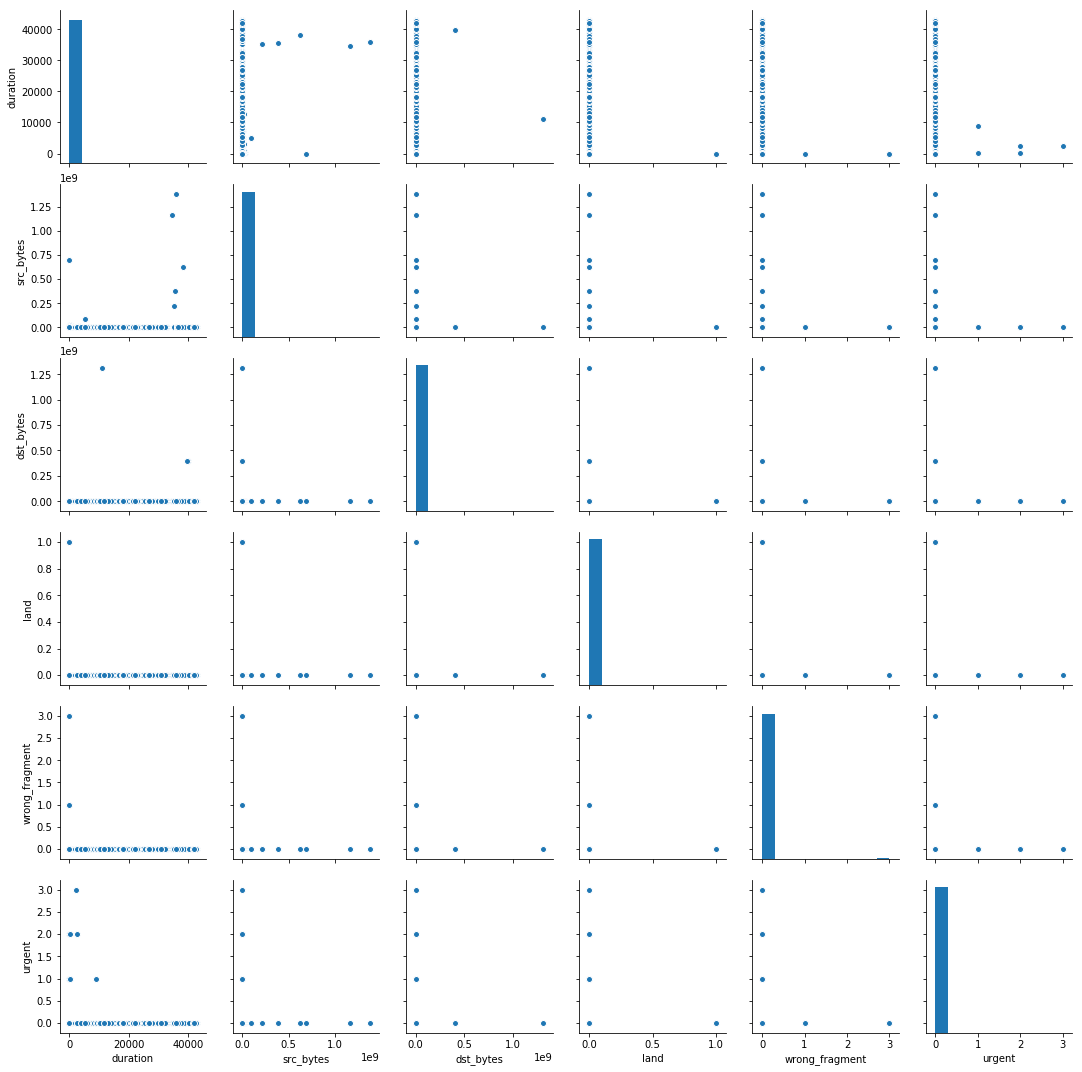

In [54]:

plt.figure(figsize = (12, 12))
sns.pairplot(kdd_train[basic_attr])
plt.show()


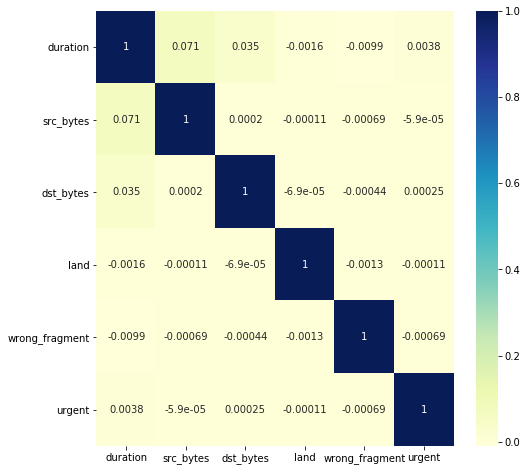

In [55]:
plt.figure(figsize = (8, 8))
sns.heatmap(kdd_train[basic_attr].corr(), annot = True, cmap="YlGnBu")
plt.show()


#### protocol_type,flag,land vs attack

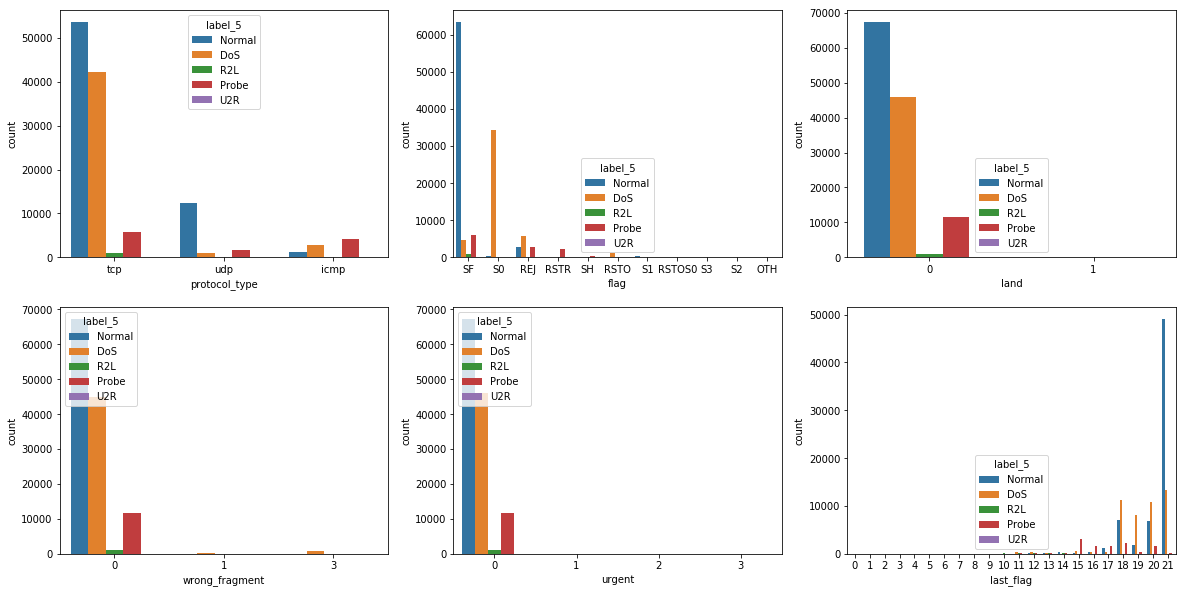

In [52]:
plt.figure(figsize=(20,10))
plt.subplot(2,3,1)
sns.countplot(x='protocol_type',data=kdd_train,hue='label_5')
plt.subplot(2,3,2)
sns.countplot(x='flag',data=kdd_train,hue='label_5')
plt.subplot(2,3,3)
sns.countplot(x='land',data=kdd_train,hue='label_5')
plt.subplot(2,3,4)
sns.countplot(x='wrong_fragment',data=kdd_train,hue='label_5')
plt.subplot(2,3,5)
sns.countplot(x='urgent',data=kdd_train,hue='label_5')
plt.subplot(2,3,6)
sns.countplot(x='last_flag',data=kdd_train,hue='label_5')


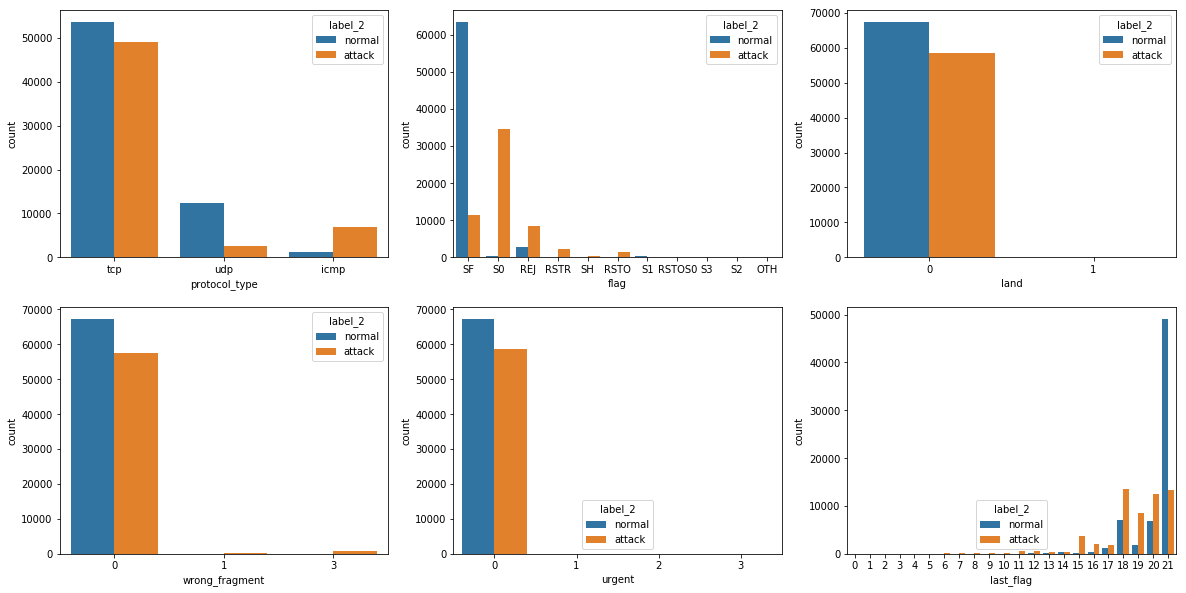

In [53]:
plt.figure(figsize=(20,10))
plt.subplot(2,3,1)
sns.countplot(x='protocol_type',data=kdd_train,hue='label_2')
plt.subplot(2,3,2)
sns.countplot(x='flag',data=kdd_train,hue='label_2')
plt.subplot(2,3,3)
sns.countplot(x='land',data=kdd_train,hue='label_2')
plt.subplot(2,3,4)
sns.countplot(x='wrong_fragment',data=kdd_train,hue='label_2')
plt.subplot(2,3,5)
sns.countplot(x='urgent',data=kdd_train,hue='label_2')
plt.subplot(2,3,6)
sns.countplot(x='last_flag',data=kdd_train,hue='label_2')

/mnt/disks/user/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "
/mnt/disks/user/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "
/mnt/disks/user/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "


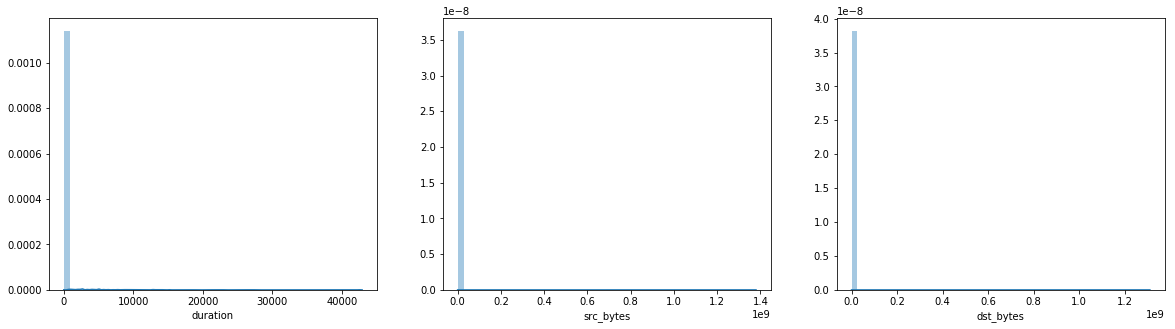

In [54]:
plt.figure(figsize=(20,5))

plt.subplot(1,3,1)
#plt.xscale('log')
#plt.yscale('log')
sns.distplot(kdd_train['duration'])
plt.subplot(1,3,2)
#plt.xscale('log')
#plt.yscale('log')
sns.distplot(kdd_train['src_bytes'])
#sns.distplot(x='src_bytes',data=kdd_train)
plt.subplot(1,3,3)
#plt.xscale('log')
#plt.yscale('log')
sns.distplot(kdd_train['dst_bytes'])
#sns.distplot(x='dst_bytes',data=kdd_train)


#### Basic attributes vz attacks

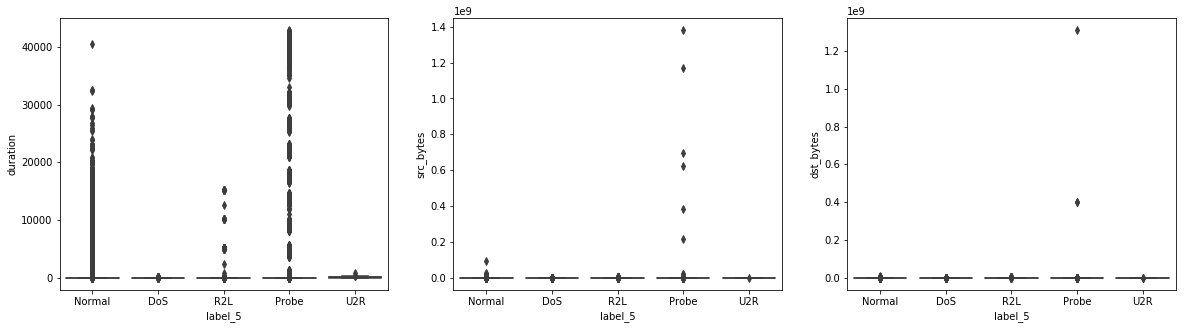

In [55]:
plt.figure(figsize=(20,5))
plt.subplot(1,3,1)
sns.boxplot(y='duration',data=kdd_train,x='label_5')
plt.subplot(1,3,2)
sns.boxplot(y='src_bytes',data=kdd_train,x='label_5')
plt.subplot(1,3,3)
sns.boxplot(y='dst_bytes',data=kdd_train,x='label_5')


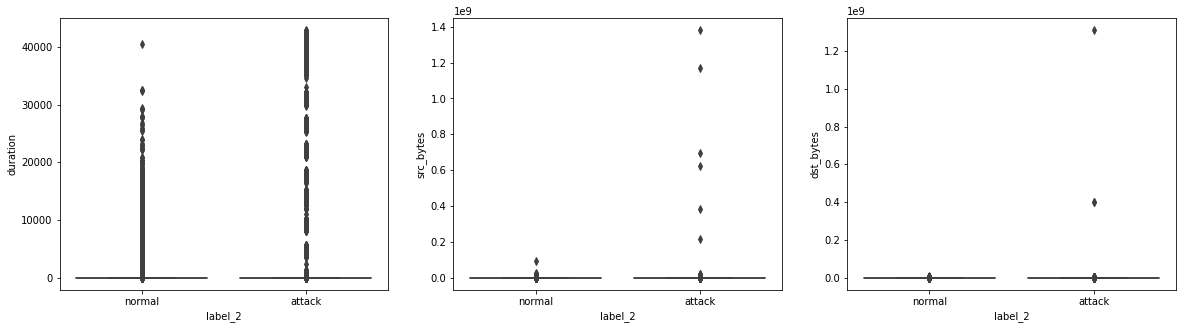

In [56]:
plt.figure(figsize=(20,5))
plt.subplot(1,3,1)
sns.boxplot(y='duration',data=kdd_train,x='label_2')
plt.subplot(1,3,2)
sns.boxplot(y='src_bytes',data=kdd_train,x='label_2')
plt.subplot(1,3,3)
sns.boxplot(y='dst_bytes',data=kdd_train,x='label_2')


### CONTENT RELATED ATTRIBUTES

    hot
    num_failed_logins
    logged_in
    num_compromised
    root_shell
    su_attempted
    num_root
    num_file_creations
    num_shells
    num_access_files
    num_outbound_cmds
    is_host_login
    is_guest_login



/mnt/disks/user/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "
/mnt/disks/user/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "
/mnt/disks/user/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "


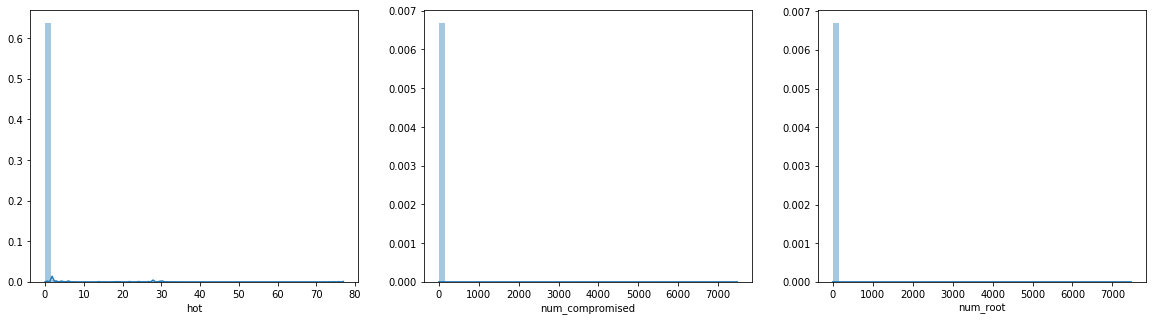

In [57]:
plt.figure(figsize=(20,5))

plt.subplot(1,3,1)
#plt.xscale('log')
#plt.yscale('log')
sns.distplot(kdd_train['hot'])

plt.subplot(1,3,2)
#plt.xscale('log')
#plt.yscale('log')
sns.distplot(kdd_train['num_compromised'])
#sns.distplot(x='src_bytes',data=kdd_train)
plt.subplot(1,3,3)
#plt.xscale('log')
#plt.yscale('log')
sns.distplot(kdd_train['num_root'])

<Figure size 864x864 with 0 Axes>

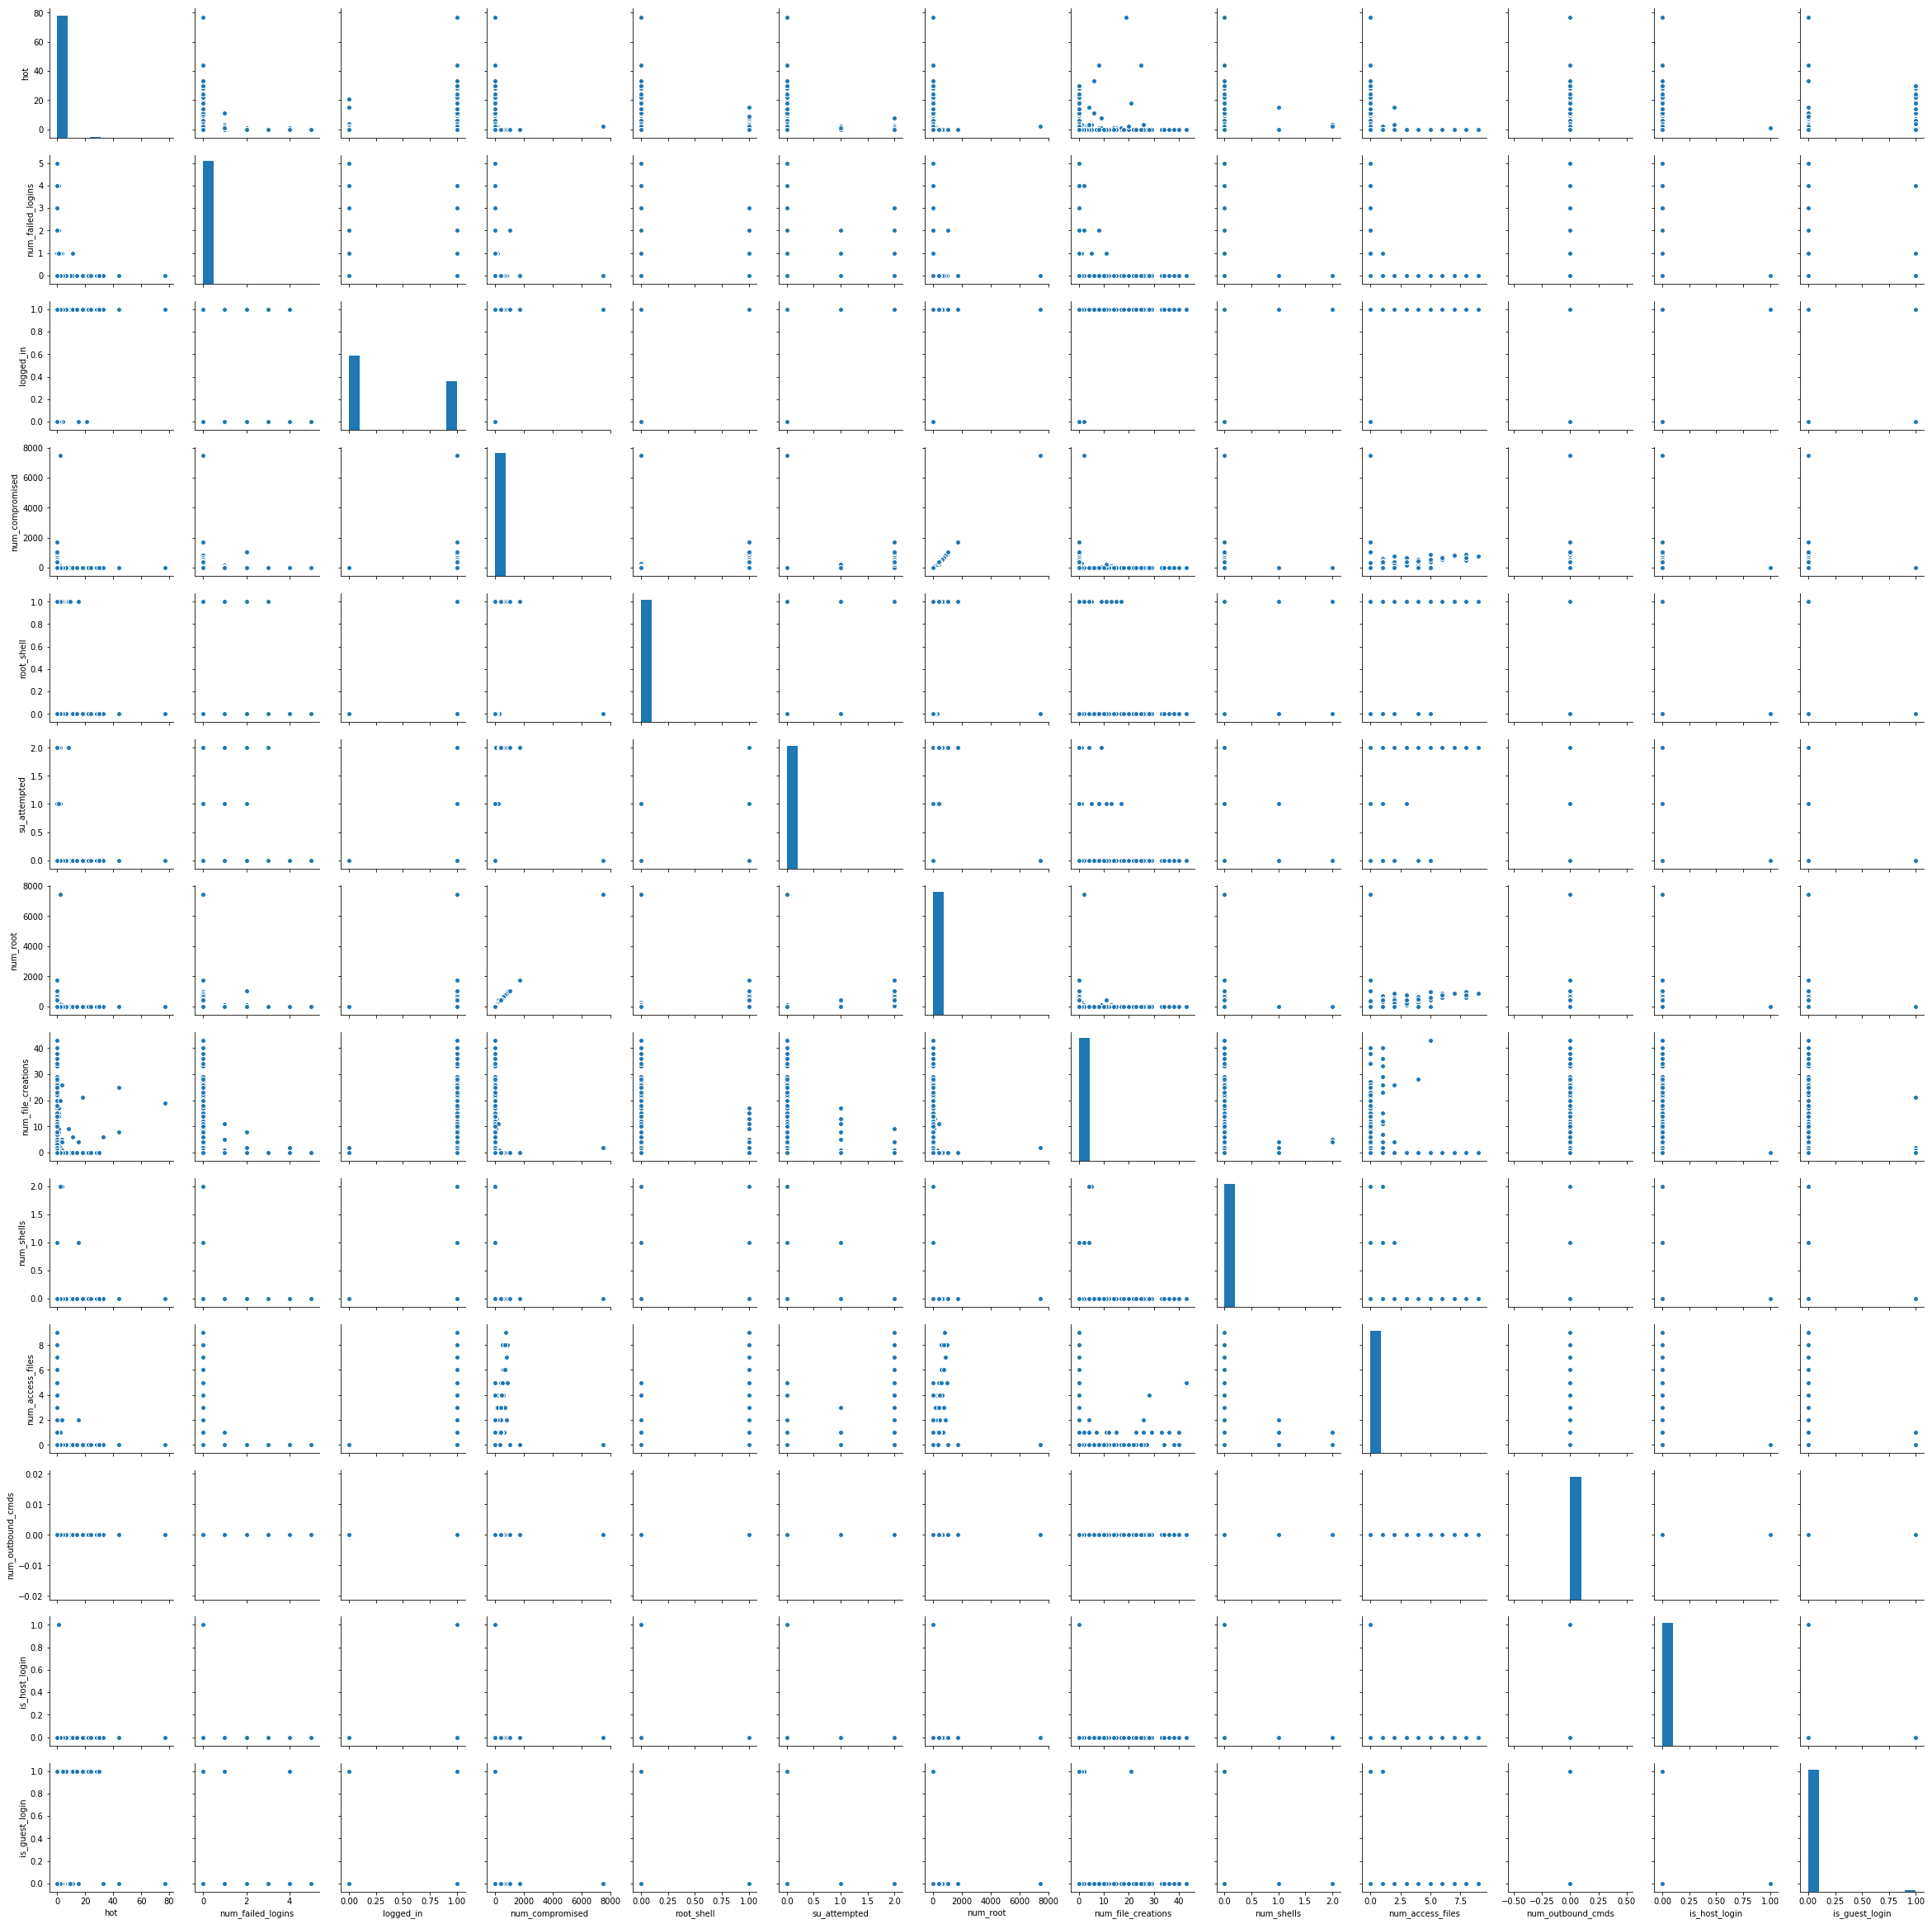

In [49]:
plt.figure(figsize = (12, 12))
sns.pairplot(kdd_train[content_attr])
plt.show()

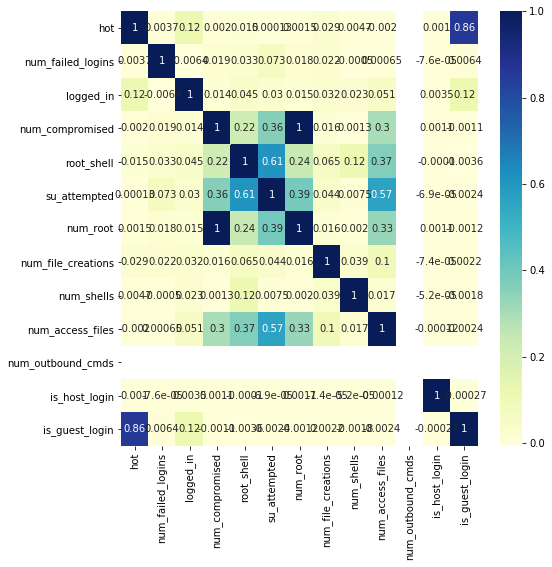

In [50]:
plt.figure(figsize = (8, 8))
sns.heatmap(kdd_train[content_attr].corr(), annot = True, cmap="YlGnBu")
plt.show()


In [51]:
kdd_train[content_attr].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
hot,125973.0,0.204409,2.149968,0.0,0.0,0.0,0.0,77.0
num_failed_logins,125973.0,0.001222,0.045239,0.0,0.0,0.0,0.0,5.0
logged_in,125973.0,0.395736,0.489010,0.0,0.0,0.0,1.0,1.0
num_compromised,125973.0,0.279250,23.942042,0.0,0.0,0.0,0.0,7479.0
root_shell,125973.0,0.001342,0.036603,0.0,0.0,0.0,0.0,1.0
su_attempted,125973.0,0.001103,0.045154,0.0,0.0,0.0,0.0,2.0
num_root,125973.0,0.302192,24.399618,0.0,0.0,0.0,0.0,7468.0
num_file_creations,125973.0,0.012669,0.483935,0.0,0.0,0.0,0.0,43.0
num_shells,125973.0,0.000413,0.022181,0.0,0.0,0.0,0.0,2.0
num_access_files,125973.0,0.004096,0.099370,0.0,0.0,0.0,0.0,9.0


In [52]:
print(pd.crosstab(kdd_train['hot'], kdd_train['label_2']),"\n")
print(pd.crosstab(kdd_train['hot'], kdd_train['label_5']))


label_2  attack  normal
hot                    
0         57215   66087
1           145     224
2           905     132
3            35      19
4            15     158
5            16      60
6             8     132
7             1       4
8             0       1
9             0       2
10            1       0
11            0       3
12            0       1
14            0      30
15            1       3
17            0       1
18            1      44
19            5      52
20            9       0
21            0       1
22            0      55
24            0      68
25            0       2
28          273       4
30            0     256
33            0       1
44            0       2
77            0       1 

label_5    DoS  Normal  Probe  R2L  U2R
hot                                    
0        44980   66087  11639  572   24
1           64     224     16   58    7
2          881     132      0   22    2
3            2      19      1   17   15
4            0     158      0   12    

In [53]:
print(pd.crosstab(kdd_train['num_failed_logins'], kdd_train['label_2']),"\n")
print(pd.crosstab(kdd_train['num_failed_logins'], kdd_train['label_5']))


label_2            attack  normal
num_failed_logins                
0                   58576   67275
1                      52      52
2                       0       9
3                       0       5
4                       1       2
5                       1       0 

label_5              DoS  Normal  Probe  R2L  U2R
num_failed_logins                                
0                  45927   67275  11655  943   51
1                      0      52      0   51    1
2                      0       9      0    0    0
3                      0       5      0    0    0
4                      0       2      1    0    0
5                      0       0      0    1    0


In [54]:
print(pd.crosstab(kdd_train['logged_in'], kdd_train['label_2']),"\n")
print(pd.crosstab(kdd_train['logged_in'], kdd_train['label_5']))


label_2    attack  normal
logged_in                
0           56635   19486
1            1995   47857 

label_5      DoS  Normal  Probe  R2L  U2R
logged_in                                
0          44970   19486  11573   86    6
1            957   47857     83  909   46


In [55]:
print(pd.crosstab(kdd_train['root_shell'], kdd_train['label_2']),"\n")
print(pd.crosstab(kdd_train['root_shell'], kdd_train['label_5']))


label_2     attack  normal
root_shell                
0            58598   67206
1               32     137 

label_5       DoS  Normal  Probe  R2L  U2R
root_shell                                
0           45927   67206  11656  989   26
1               0     137      0    6   26


In [56]:
print(pd.crosstab(kdd_train['su_attempted'], kdd_train['label_2']),"\n")
print(pd.crosstab(kdd_train['su_attempted'], kdd_train['label_5']))


label_2       attack  normal
su_attempted                
0              58629   67264
1                  1      20
2                  0      59 

label_5         DoS  Normal  Probe  R2L  U2R
su_attempted                                
0             45927   67264  11656  994   52
1                 0      20      0    1    0
2                 0      59      0    0    0


In [57]:
print(pd.crosstab(kdd_train['su_attempted'], kdd_train['label_2']),"\n")
print(pd.crosstab(kdd_train['su_attempted'], kdd_train['label_5']))


label_2       attack  normal
su_attempted                
0              58629   67264
1                  1      20
2                  0      59 

label_5         DoS  Normal  Probe  R2L  U2R
su_attempted                                
0             45927   67264  11656  994   52
1                 0      20      0    1    0
2                 0      59      0    0    0


In [58]:
print(pd.crosstab(kdd_train['num_file_creations'], kdd_train['label_2']),"\n")
print(pd.crosstab(kdd_train['num_file_creations'], kdd_train['label_5']))


label_2             attack  normal
num_file_creations                
0                    58596   67090
1                       21     130
2                        4      37
3                        0       5
4                        7       6
5                        0       5
6                        0       3
7                        0       4
8                        0       5
9                        0       2
10                       0       5
11                       0       4
12                       0       4
13                       0       2
14                       0       3
15                       0       5
16                       0       1
17                       0       5
18                       1       3
19                       0       1
20                       0       3
21                       1       0
22                       0       1
23                       0       2
25                       0       3
26                       0       3
27                  

In [59]:
print(pd.crosstab(kdd_train['num_shells'], kdd_train['label_2']),"\n")
print(pd.crosstab(kdd_train['num_shells'], kdd_train['label_5']))


label_2     attack  normal
num_shells                
0            58622   67304
1                5      37
2                3       2 

label_5       DoS  Normal  Probe  R2L  U2R
num_shells                                
0           45927   67304  11656  992   47
1               0      37      0    2    3
2               0       2      0    1    2


In [60]:
print(pd.crosstab(kdd_train['num_access_files'], kdd_train['label_2']),"\n")
print(pd.crosstab(kdd_train['num_access_files'], kdd_train['label_5']))


label_2           attack  normal
num_access_files                
0                  58620   66982
1                      9     304
2                      1      28
3                      0       8
4                      0       5
5                      0       6
6                      0       4
7                      0       2
8                      0       3
9                      0       1 

label_5             DoS  Normal  Probe  R2L  U2R
num_access_files                                
0                 45927   66982  11656  986   51
1                     0     304      0    8    1
2                     0      28      0    1    0
3                     0       8      0    0    0
4                     0       5      0    0    0
5                     0       6      0    0    0
6                     0       4      0    0    0
7                     0       2      0    0    0
8                     0       3      0    0    0
9                     0       1      0    0    0


In [61]:
print(pd.crosstab(kdd_train['num_outbound_cmds'], kdd_train['label_2']),"\n")
print(pd.crosstab(kdd_train['num_outbound_cmds'], kdd_train['label_5']))


label_2            attack  normal
num_outbound_cmds                
0                   58630   67343 

label_5              DoS  Normal  Probe  R2L  U2R
num_outbound_cmds                                
0                  45927   67343  11656  995   52


In [62]:
print(pd.crosstab(kdd_train['is_host_login'], kdd_train['label_2']),"\n")
print(pd.crosstab(kdd_train['is_host_login'], kdd_train['label_5']))

label_2        attack  normal
is_host_login                
0               58630   67342
1                   0       1 

label_5          DoS  Normal  Probe  R2L  U2R
is_host_login                                
0              45927   67342  11656  995   52
1                  0       1      0    0    0


In [63]:
print(pd.crosstab(kdd_train['is_guest_login'], kdd_train['label_2']),"\n")
print(pd.crosstab(kdd_train['is_guest_login'], kdd_train['label_5']))

label_2         attack  normal
is_guest_login                
0                58316   66470
1                  314     873 

label_5           DoS  Normal  Probe  R2L  U2R
is_guest_login                                
0               45927   66470  11655  682   52
1                   0     873      1  313    0


### No variance in data for num_outbound_cmds and is_host_login . Hence can be dropped

In [64]:
categ_content=['hot','num_failed_logins','num_file_creations','num_shells','num_access_files']

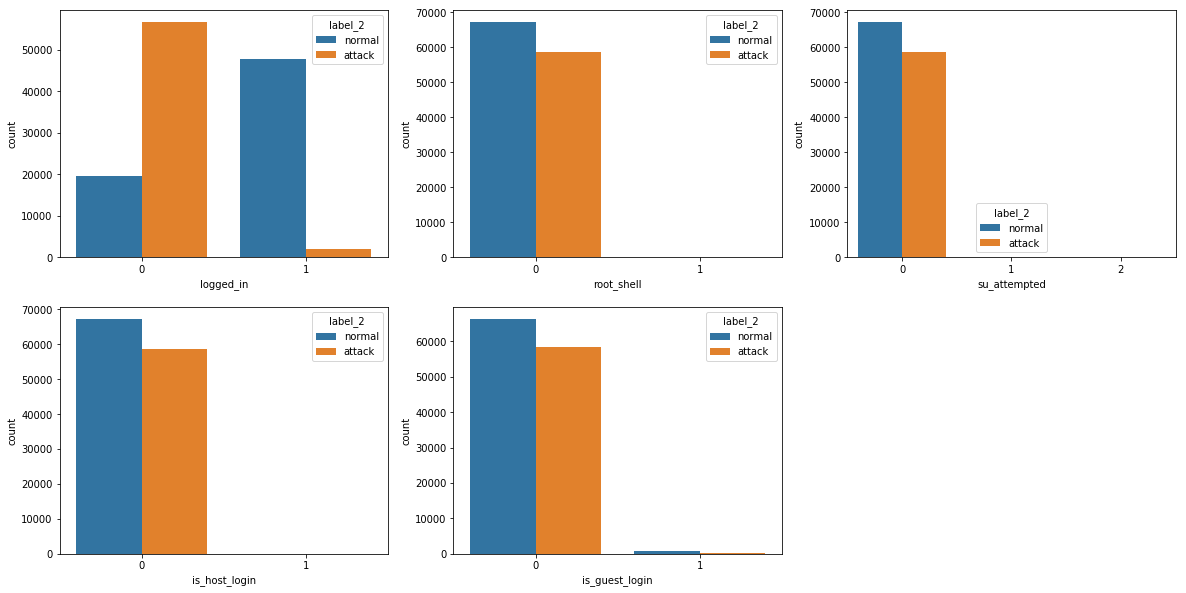

In [54]:
plt.figure(figsize=(20,10))
plt.subplot(2,3,1)
sns.countplot(x='logged_in',data=kdd_train,hue='label_2')
plt.subplot(2,3,2)
sns.countplot(x='root_shell',data=kdd_train,hue='label_2')
plt.subplot(2,3,3)
sns.countplot(x='su_attempted',data=kdd_train,hue='label_2')
plt.subplot(2,3,4)
sns.countplot(x='is_host_login',data=kdd_train,hue='label_2')
plt.subplot(2,3,5)
sns.countplot(x='is_guest_login',data=kdd_train,hue='label_2')


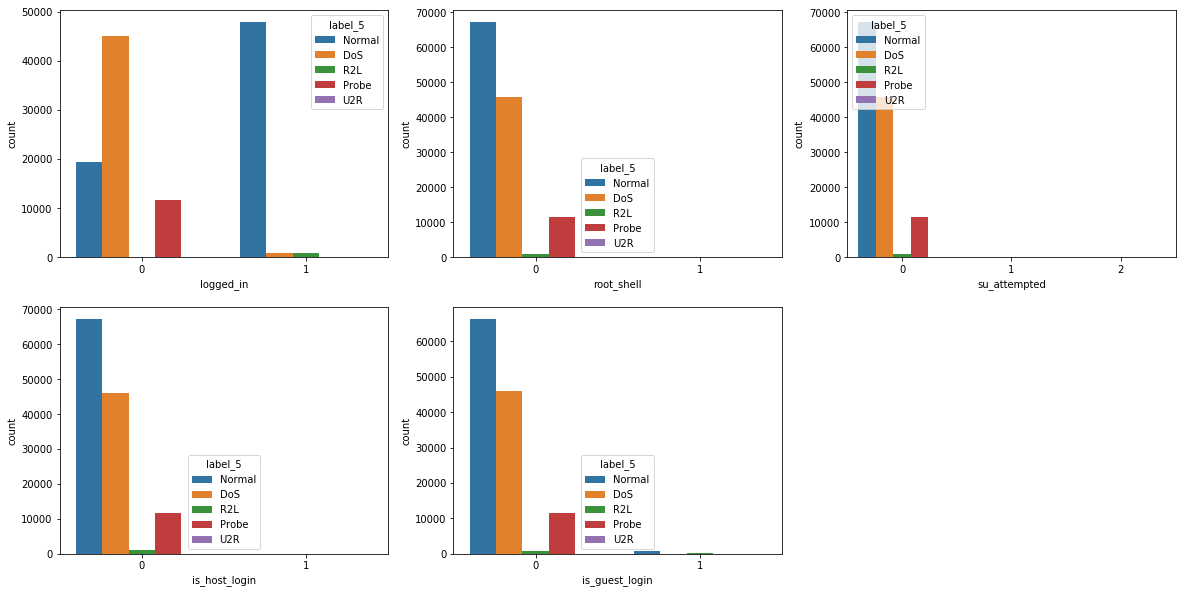

In [55]:
plt.figure(figsize=(20,10))
plt.subplot(2,3,1)
sns.countplot(x='logged_in',data=kdd_train,hue='label_5')
plt.subplot(2,3,2)
sns.countplot(x='root_shell',data=kdd_train,hue='label_5')
plt.subplot(2,3,3)
sns.countplot(x='su_attempted',data=kdd_train,hue='label_5')
plt.subplot(2,3,4)
sns.countplot(x='is_host_login',data=kdd_train,hue='label_5')
plt.subplot(2,3,5)
sns.countplot(x='is_guest_login',data=kdd_train,hue='label_5')


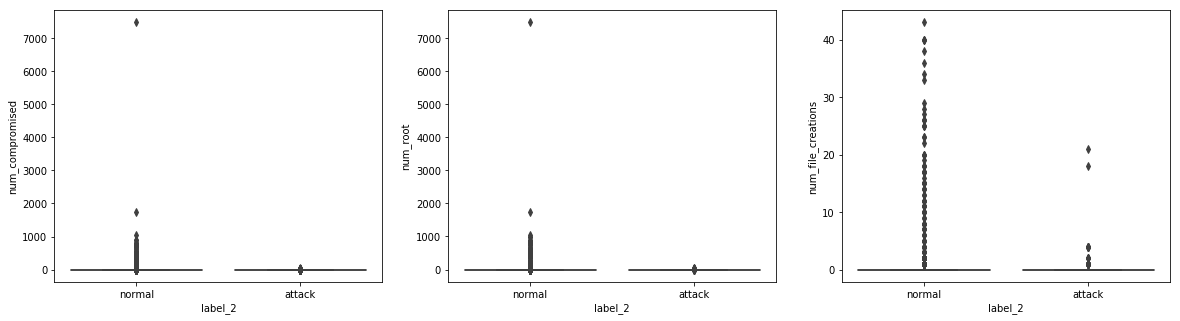

In [66]:
plt.figure(figsize=(20,5))
plt.subplot(1,3,1)
sns.boxplot(y='num_compromised',data=kdd_train,x='label_2')
plt.subplot(1,3,2)
sns.boxplot(y='num_root',data=kdd_train,x='label_2')
plt.subplot(1,3,3)
sns.boxplot(y='num_file_creations',data=kdd_train,x='label_2')


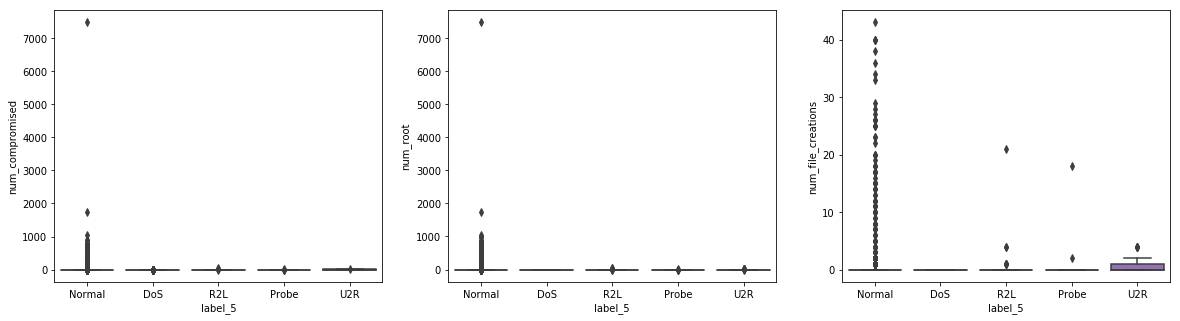

In [67]:
plt.figure(figsize=(20,5))
plt.subplot(1,3,1)
sns.boxplot(y='num_compromised',data=kdd_train,x='label_5')
plt.subplot(1,3,2)
sns.boxplot(y='num_root',data=kdd_train,x='label_5')
plt.subplot(1,3,3)
sns.boxplot(y='num_file_creations',data=kdd_train,x='label_5')


### TIME RELATED ATTRIBUTES
count
srv_count
serror_rate
srv_serror_rate
rerror_rate
srv_rerror_rate
same_srv_rate
diff_srv_rate
srv_diff_host_rate


In [68]:
kdd_train[time_attr].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
count,125973.0,84.107555,114.508607,0.0,2.00,14.0,143.00,511.0
srv_count,125973.0,27.737888,72.635840,0.0,2.00,8.0,18.00,511.0
serror_rate,125973.0,0.284485,0.446456,0.0,0.00,0.0,1.00,1.0
srv_serror_rate,125973.0,0.282485,0.447022,0.0,0.00,0.0,1.00,1.0
rerror_rate,125973.0,0.119958,0.320436,0.0,0.00,0.0,0.00,1.0
srv_rerror_rate,125973.0,0.121183,0.323647,0.0,0.00,0.0,0.00,1.0
same_srv_rate,125973.0,0.660928,0.439623,0.0,0.09,1.0,1.00,1.0
diff_srv_rate,125973.0,0.063053,0.180314,0.0,0.00,0.0,0.06,1.0
srv_diff_host_rate,125973.0,0.097322,0.259830,0.0,0.00,0.0,0.00,1.0


/mnt/disks/user/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "
/mnt/disks/user/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "
/mnt/disks/user/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "
/mnt/disks/user/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "
/mnt/disks/user/anaconda

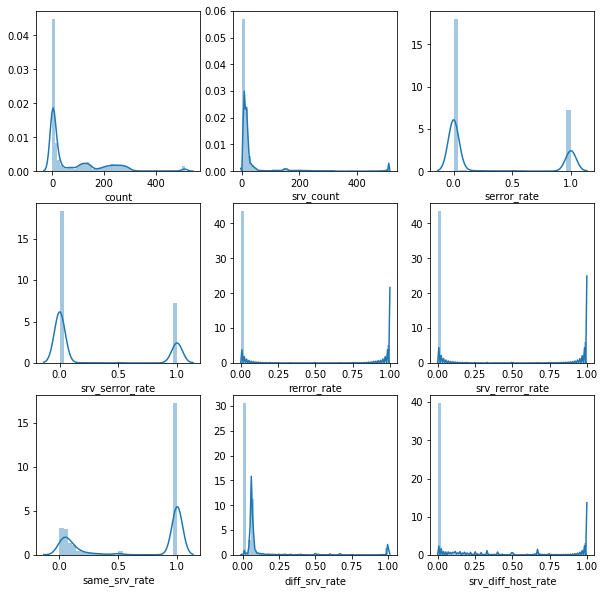

In [70]:
plt.figure(figsize=(10,10))

plt.subplot(3,3,1)
sns.distplot(kdd_train['count'])

plt.subplot(3,3,2)
sns.distplot(kdd_train['srv_count'])

plt.subplot(3,3,3)
sns.distplot(kdd_train['serror_rate'])

plt.subplot(3,3,4)
sns.distplot(kdd_train['srv_serror_rate'])


plt.subplot(3,3,5)
sns.distplot(kdd_train['rerror_rate'])

plt.subplot(3,3,6)
sns.distplot(kdd_train['srv_rerror_rate'])

plt.subplot(3,3,7)
sns.distplot(kdd_train['same_srv_rate'])

plt.subplot(3,3,8)
sns.distplot(kdd_train['diff_srv_rate'])

plt.subplot(3,3,9)
sns.distplot(kdd_train['srv_diff_host_rate'])



<Figure size 864x864 with 0 Axes>

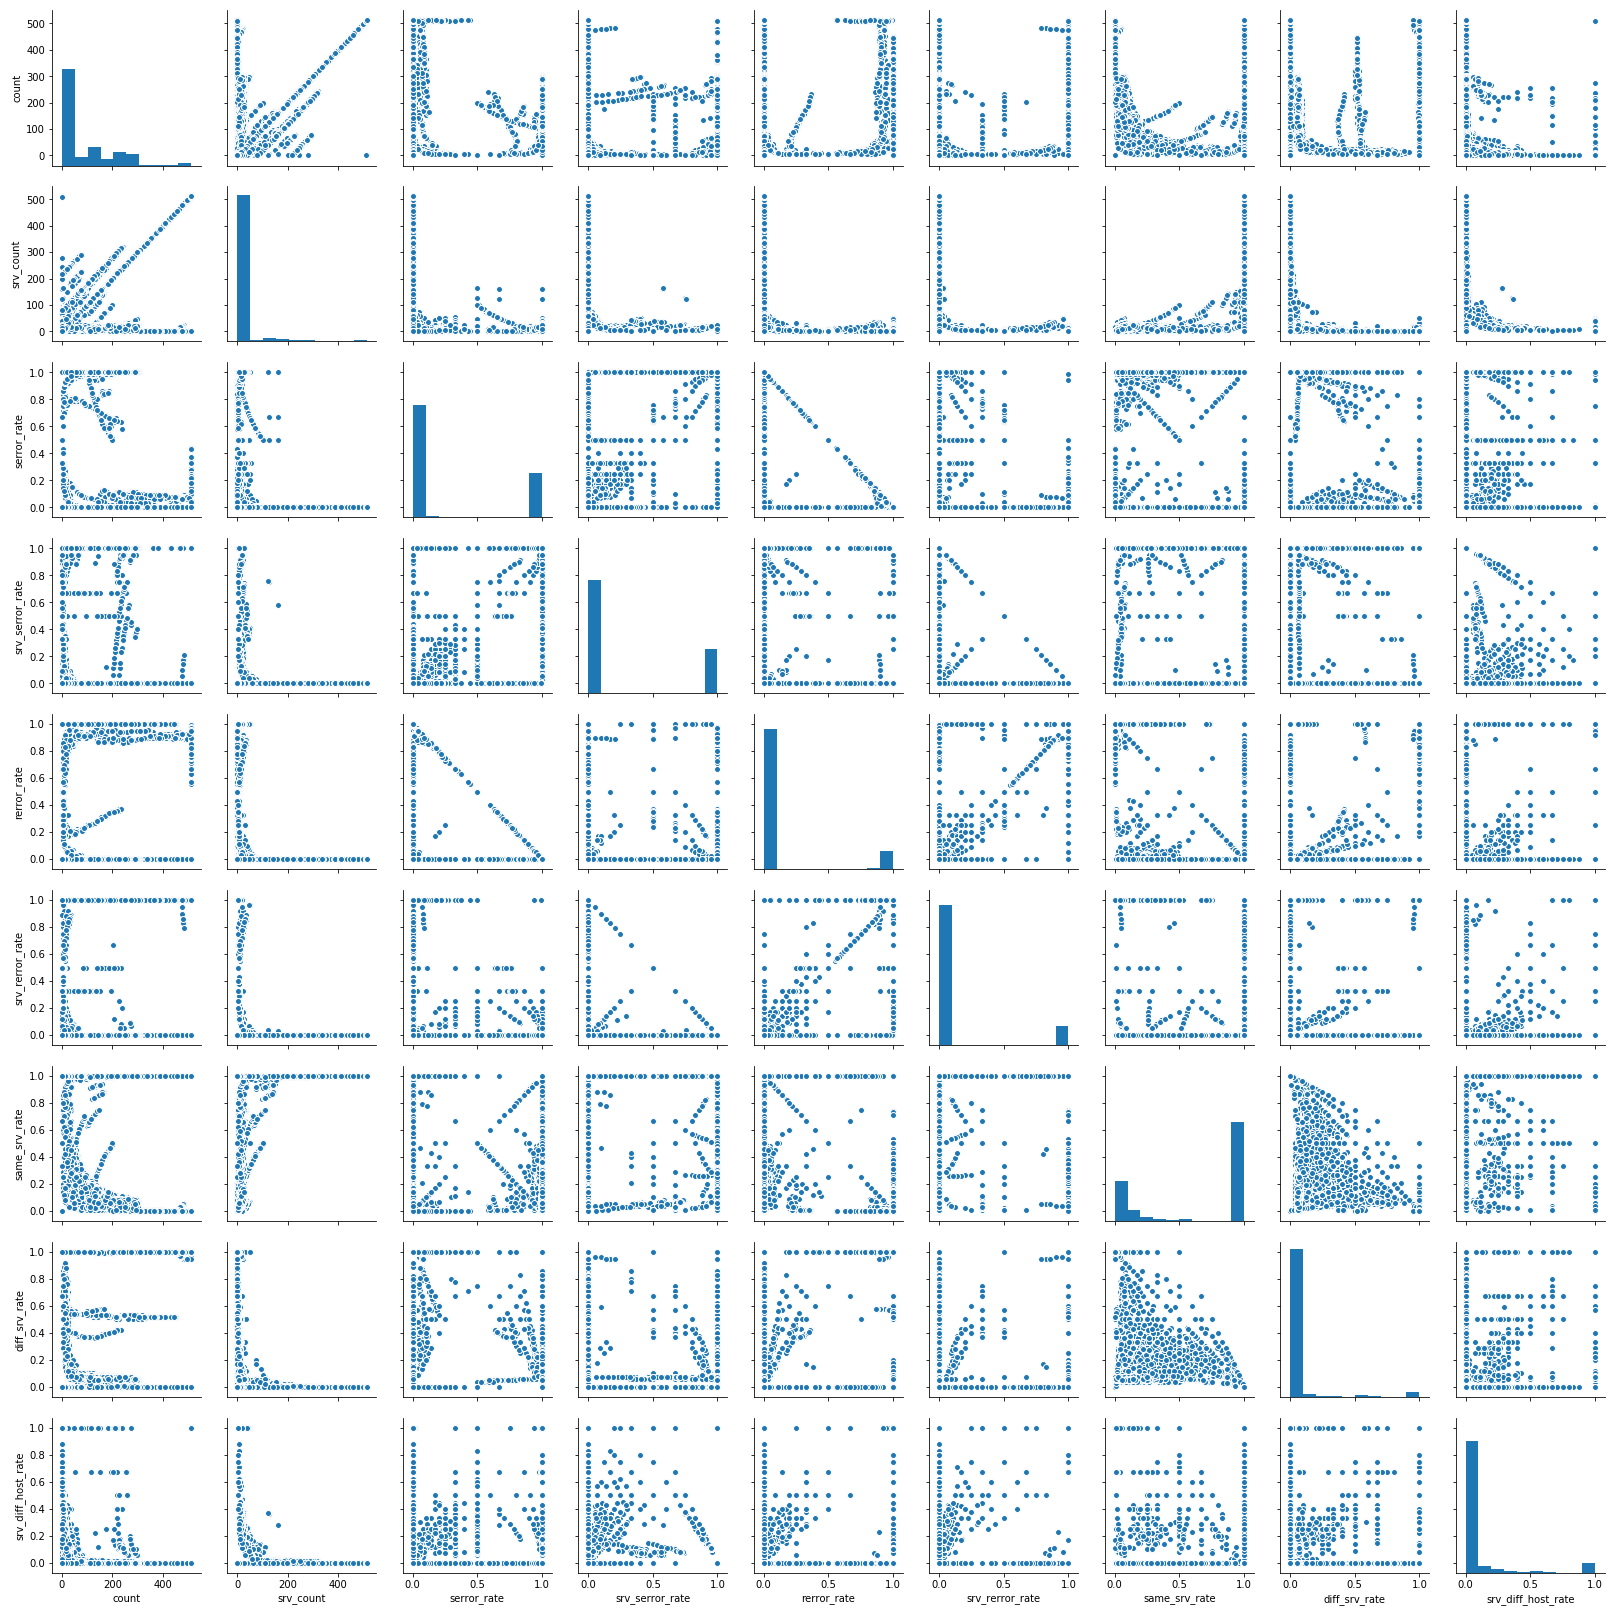

In [69]:
plt.figure(figsize = (12, 12))
sns.pairplot(kdd_train[time_attr])
plt.show()

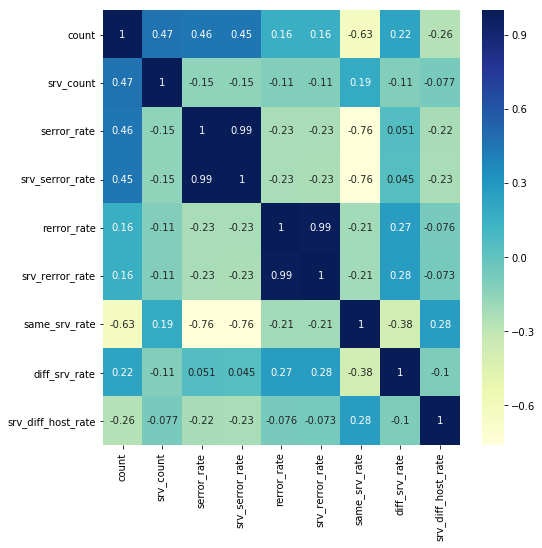

In [70]:
plt.figure(figsize = (8, 8))
sns.heatmap(kdd_train[time_attr].corr(), annot = True, cmap="YlGnBu")
plt.show()


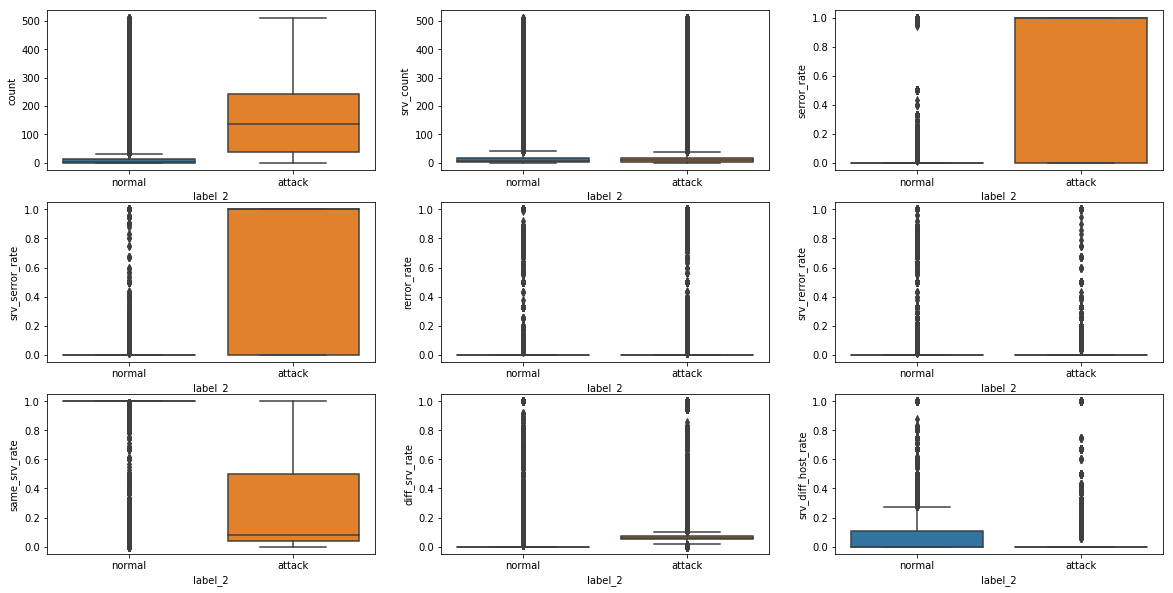

In [71]:
plt.figure(figsize=(20,10))
plt.subplot(3,3,1)
sns.boxplot(y='count',data=kdd_train,x='label_2')
plt.subplot(3,3,2)
sns.boxplot(y='srv_count',data=kdd_train,x='label_2')
plt.subplot(3,3,3)
sns.boxplot(y='serror_rate',data=kdd_train,x='label_2')
plt.subplot(3,3,4)
sns.boxplot(y='srv_serror_rate',data=kdd_train,x='label_2')
plt.subplot(3,3,5)
sns.boxplot(y='rerror_rate',data=kdd_train,x='label_2')
plt.subplot(3,3,6)
sns.boxplot(y='srv_rerror_rate',data=kdd_train,x='label_2')
plt.subplot(3,3,7)
sns.boxplot(y='same_srv_rate',data=kdd_train,x='label_2')
plt.subplot(3,3,8)
sns.boxplot(y='diff_srv_rate',data=kdd_train,x='label_2')
plt.subplot(3,3,9)
sns.boxplot(y='srv_diff_host_rate',data=kdd_train,x='label_2')


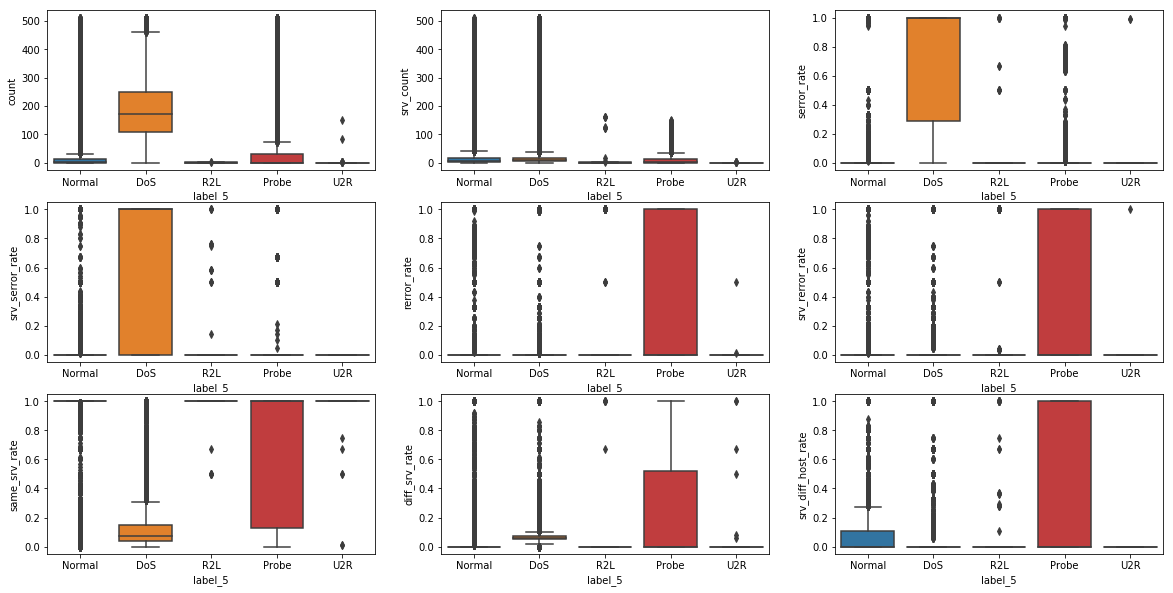

In [72]:
plt.figure(figsize=(20,10))
plt.subplot(3,3,1)
sns.boxplot(y='count',data=kdd_train,x='label_5')
plt.subplot(3,3,2)
sns.boxplot(y='srv_count',data=kdd_train,x='label_5')
plt.subplot(3,3,3)
sns.boxplot(y='serror_rate',data=kdd_train,x='label_5')
plt.subplot(3,3,4)
sns.boxplot(y='srv_serror_rate',data=kdd_train,x='label_5')
plt.subplot(3,3,5)
sns.boxplot(y='rerror_rate',data=kdd_train,x='label_5')
plt.subplot(3,3,6)
sns.boxplot(y='srv_rerror_rate',data=kdd_train,x='label_5')
plt.subplot(3,3,7)
sns.boxplot(y='same_srv_rate',data=kdd_train,x='label_5')
plt.subplot(3,3,8)
sns.boxplot(y='diff_srv_rate',data=kdd_train,x='label_5')
plt.subplot(3,3,9)
sns.boxplot(y='srv_diff_host_rate',data=kdd_train,x='label_5')


plt.figure(figsize=(20,10))
plt.subplot(3,3,1)
sns.distplot(kdd_train['count'],rug=True)
plt.subplot(3,3,2)
sns.distplot(kdd_train['srv_count'],rug=True)
plt.subplot(3,3,3)
sns.distplot(kdd_train['serror_rate'],rug=True)
plt.subplot(3,3,4)
sns.distplot(kdd_train['srv_serror_rate'],rug=True) 

###  HOST BASED ATTRIBUTES

    dst_host_count
    dst_host_srv_count
    dst_host_same_srv_rate
    dst_host_diff_srv_rate
    dst_host_same_src_port_rate
    dst_host_srv_diff_host_rate
    dst_host_serror_rate
    dst_host_srv_serror_rate
    dst_host_rerror_rate
    dst_host_srv_rerror_rate


/mnt/disks/user/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "
/mnt/disks/user/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "
/mnt/disks/user/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "
/mnt/disks/user/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "
/mnt/disks/user/anaconda

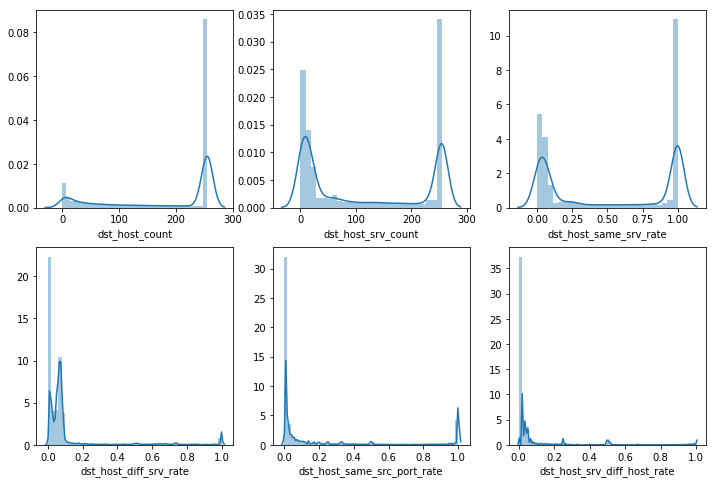

In [76]:
plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
sns.distplot(kdd_train['dst_host_count'])

plt.subplot(2,3,2)
sns.distplot(kdd_train['dst_host_srv_count'])

plt.subplot(2,3,3)
sns.distplot(kdd_train['dst_host_same_srv_rate'])

plt.subplot(2,3,4)
sns.distplot(kdd_train['dst_host_diff_srv_rate'])


plt.subplot(2,3,5)
sns.distplot(kdd_train['dst_host_same_src_port_rate'])

plt.subplot(2,3,6)
sns.distplot(kdd_train['dst_host_srv_diff_host_rate'])

/mnt/disks/user/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "
/mnt/disks/user/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "
/mnt/disks/user/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "
/mnt/disks/user/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "


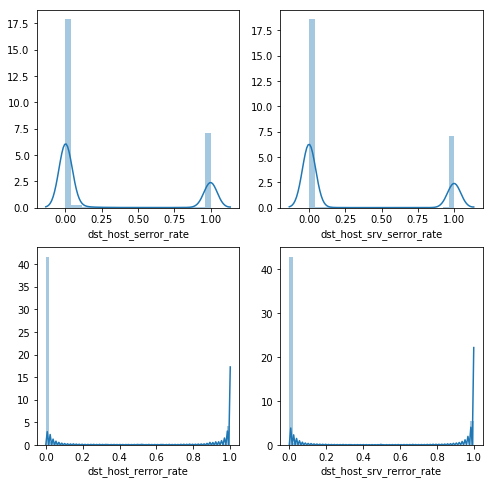

In [72]:
plt.figure(figsize=(8,8))

plt.subplot(2,2,1)
sns.distplot(kdd_train['dst_host_serror_rate'])

plt.subplot(2,2,2)
sns.distplot(kdd_train['dst_host_srv_serror_rate'])

plt.subplot(2,2,3)
sns.distplot(kdd_train['dst_host_rerror_rate'])


plt.subplot(2,2,4)
sns.distplot(kdd_train['dst_host_srv_rerror_rate'])

In [74]:
kdd_train[host_attr].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
dst_host_count,125973.0,182.148945,99.206213,0.0,82.00,255.00,255.00,255.0
dst_host_srv_count,125973.0,115.653005,110.702741,0.0,10.00,63.00,255.00,255.0
dst_host_same_srv_rate,125973.0,0.521242,0.448949,0.0,0.05,0.51,1.00,1.0
dst_host_diff_srv_rate,125973.0,0.082951,0.188922,0.0,0.00,0.02,0.07,1.0
dst_host_same_src_port_rate,125973.0,0.148379,0.308997,0.0,0.00,0.00,0.06,1.0
dst_host_srv_diff_host_rate,125973.0,0.032542,0.112564,0.0,0.00,0.00,0.02,1.0
dst_host_serror_rate,125973.0,0.284452,0.444784,0.0,0.00,0.00,1.00,1.0
dst_host_srv_serror_rate,125973.0,0.278485,0.445669,0.0,0.00,0.00,1.00,1.0
dst_host_rerror_rate,125973.0,0.118832,0.306557,0.0,0.00,0.00,0.00,1.0
dst_host_srv_rerror_rate,125973.0,0.120240,0.319459,0.0,0.00,0.00,0.00,1.0


<Figure size 864x864 with 0 Axes>

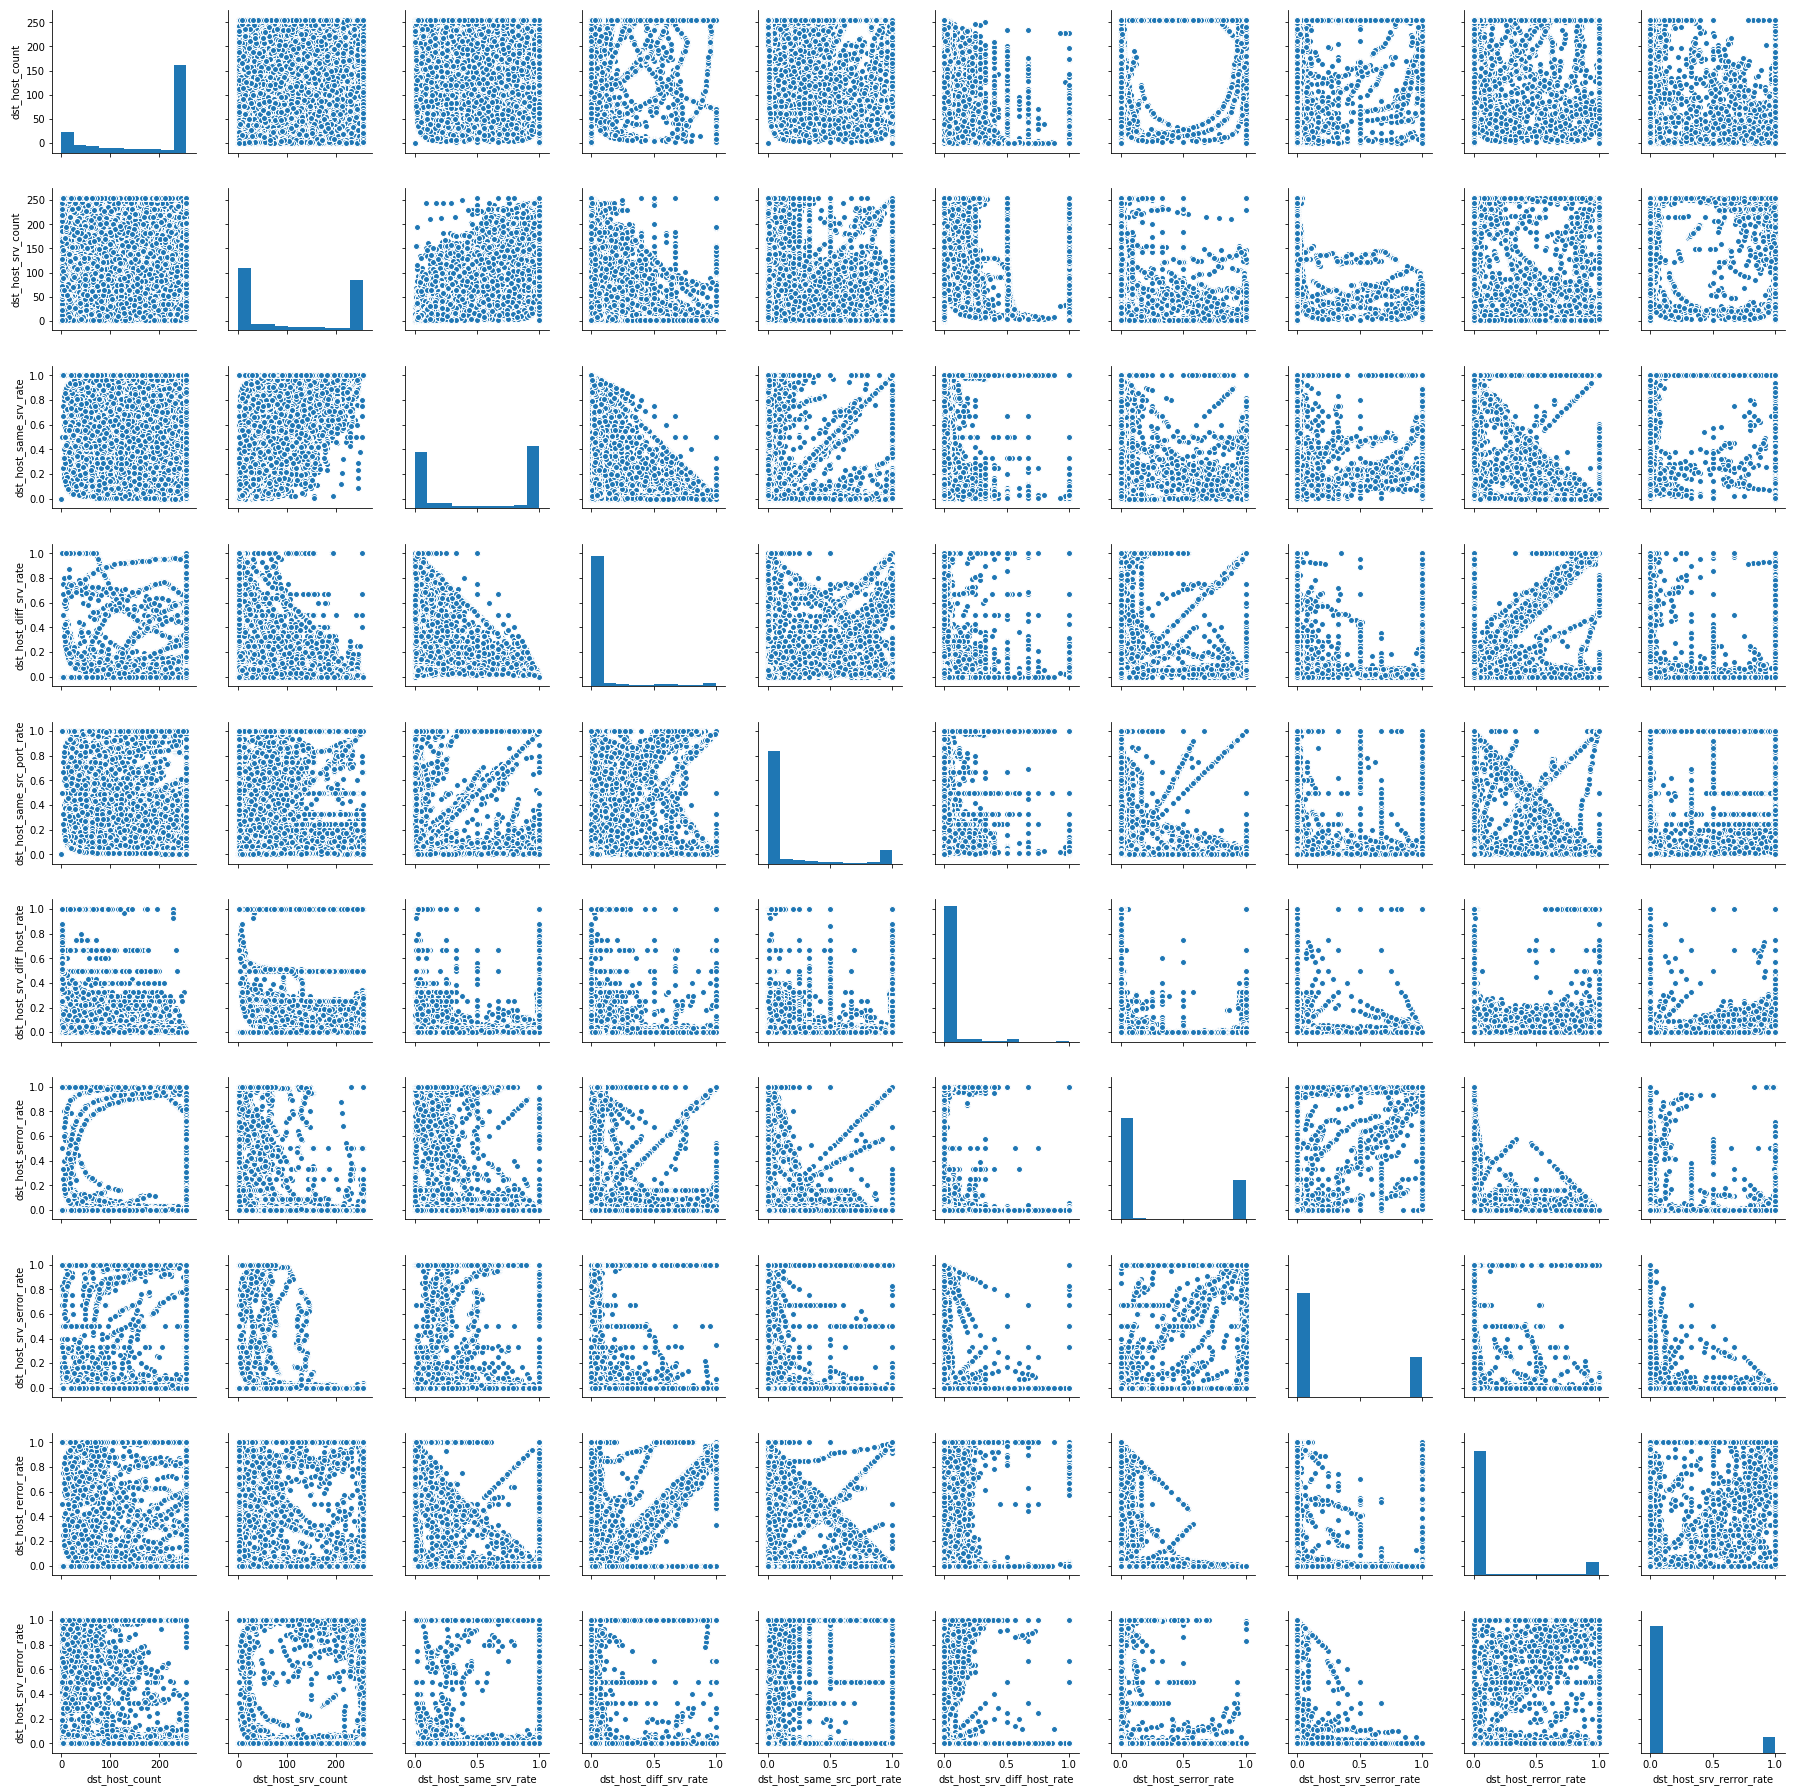

In [75]:
plt.figure(figsize = (12, 12))
sns.pairplot(kdd_train[host_attr])
plt.show()

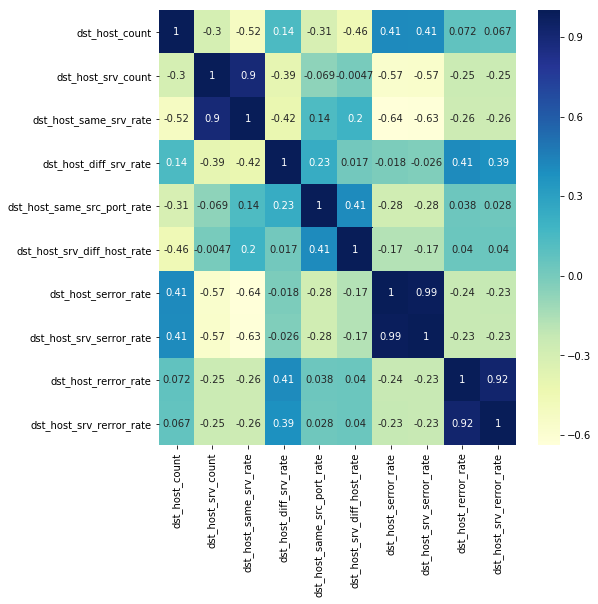

In [76]:
plt.figure(figsize = (8, 8))
sns.heatmap(kdd_train[host_attr].corr(), annot = True, cmap="YlGnBu")
plt.show()


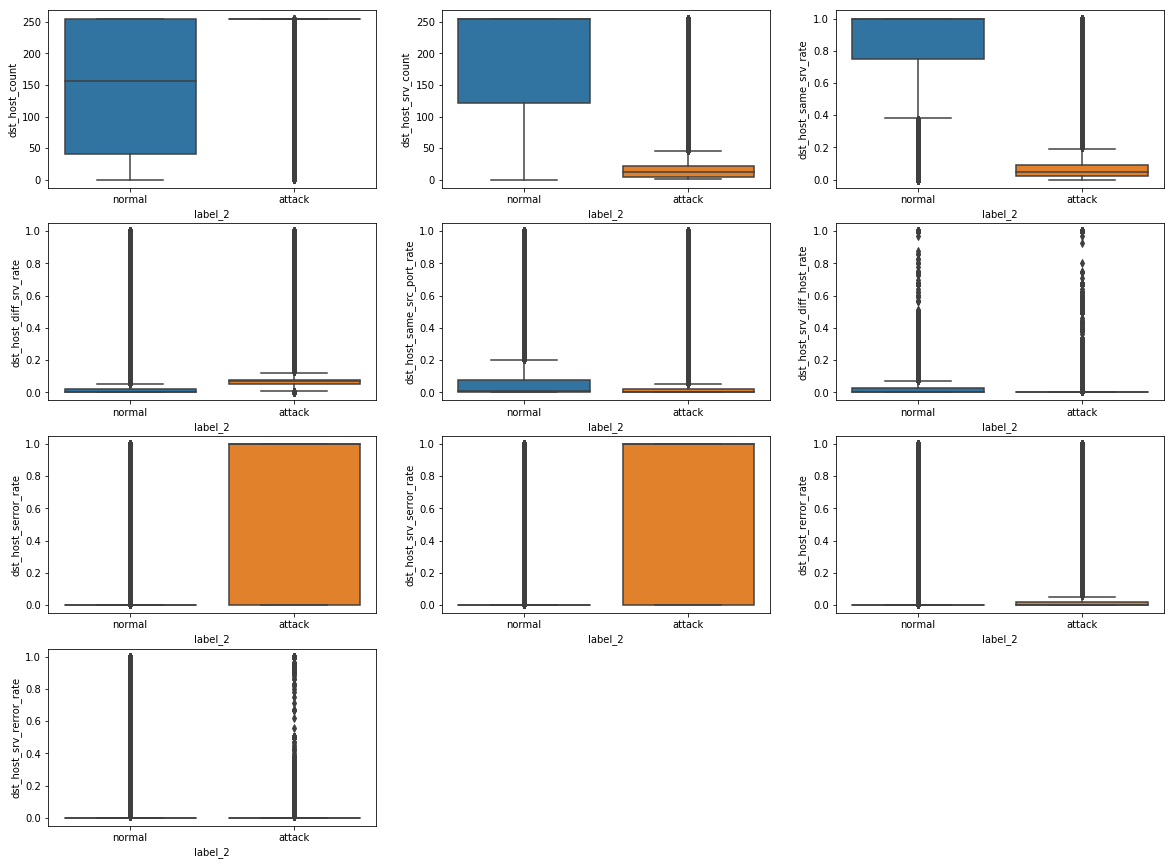

In [77]:
plt.figure(figsize=(20,15))
plt.subplot(4,3,1)
sns.boxplot(y='dst_host_count',data=kdd_train,x='label_2')
plt.subplot(4,3,2)
sns.boxplot(y='dst_host_srv_count',data=kdd_train,x='label_2')
plt.subplot(4,3,3)
sns.boxplot(y='dst_host_same_srv_rate',data=kdd_train,x='label_2')
plt.subplot(4,3,4)
sns.boxplot(y='dst_host_diff_srv_rate',data=kdd_train,x='label_2')
plt.subplot(4,3,5)
sns.boxplot(y='dst_host_same_src_port_rate',data=kdd_train,x='label_2')
plt.subplot(4,3,6)
sns.boxplot(y='dst_host_srv_diff_host_rate',data=kdd_train,x='label_2')
plt.subplot(4,3,7)
sns.boxplot(y='dst_host_serror_rate',data=kdd_train,x='label_2')
plt.subplot(4,3,8)
sns.boxplot(y='dst_host_srv_serror_rate',data=kdd_train,x='label_2')
plt.subplot(4,3,9)
sns.boxplot(y='dst_host_rerror_rate',data=kdd_train,x='label_2')
plt.subplot(4,3,10)
sns.boxplot(y='dst_host_srv_rerror_rate',data=kdd_train,x='label_2')


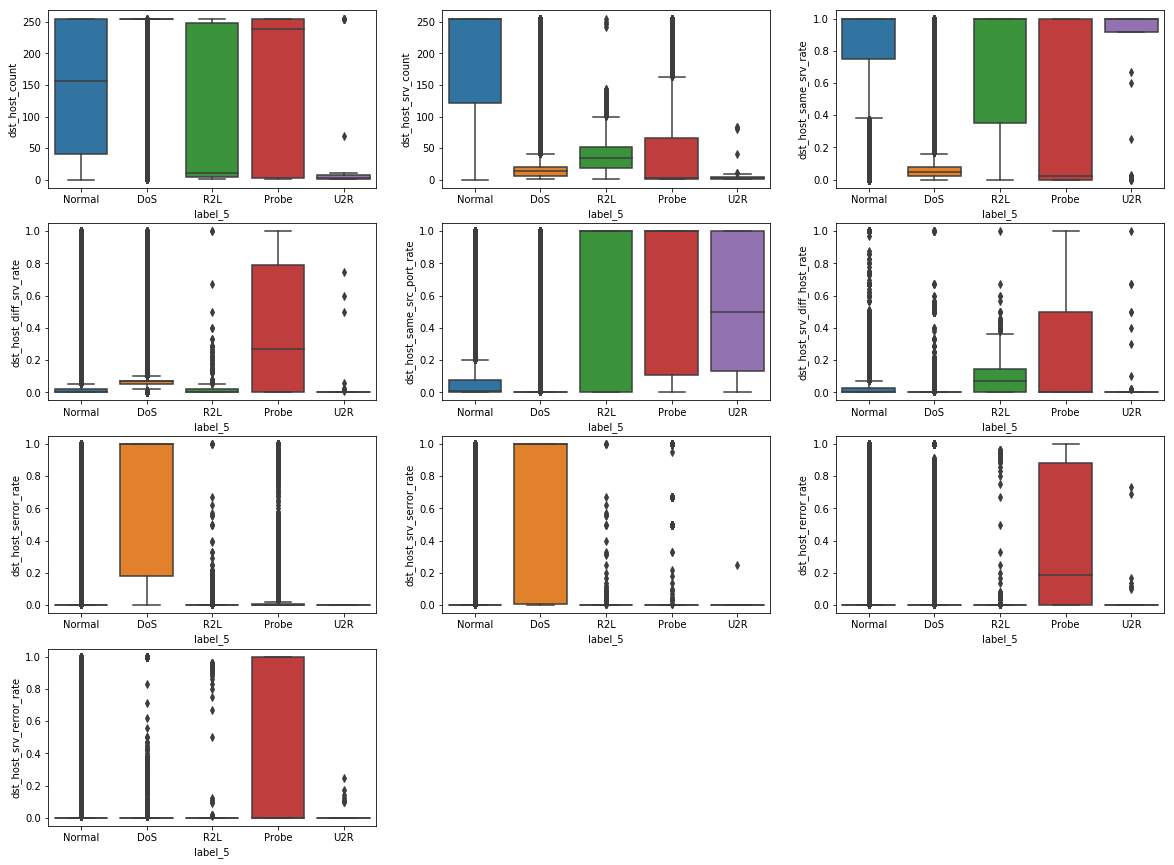

In [78]:
plt.figure(figsize=(20,15))
plt.subplot(4,3,1)
sns.boxplot(y='dst_host_count',data=kdd_train,x='label_5')
plt.subplot(4,3,2)
sns.boxplot(y='dst_host_srv_count',data=kdd_train,x='label_5')
plt.subplot(4,3,3)
sns.boxplot(y='dst_host_same_srv_rate',data=kdd_train,x='label_5')
plt.subplot(4,3,4)
sns.boxplot(y='dst_host_diff_srv_rate',data=kdd_train,x='label_5')
plt.subplot(4,3,5)
sns.boxplot(y='dst_host_same_src_port_rate',data=kdd_train,x='label_5')
plt.subplot(4,3,6)
sns.boxplot(y='dst_host_srv_diff_host_rate',data=kdd_train,x='label_5')
plt.subplot(4,3,7)
sns.boxplot(y='dst_host_serror_rate',data=kdd_train,x='label_5')
plt.subplot(4,3,8)
sns.boxplot(y='dst_host_srv_serror_rate',data=kdd_train,x='label_5')
plt.subplot(4,3,9)
sns.boxplot(y='dst_host_rerror_rate',data=kdd_train,x='label_5')
plt.subplot(4,3,10)
sns.boxplot(y='dst_host_srv_rerror_rate',data=kdd_train,x='label_5')


#### Top n correlation

In [79]:
def get_redundant_pairs(df):
    '''Get diagonal and lower triangular pairs of correlation matrix'''
    pairs_to_drop = set()
    cols = df.columns
    for i in range(0, df.shape[1]):
        for j in range(0, i+1):
            pairs_to_drop.add((cols[i], cols[j]))
    return pairs_to_drop

def get_top_abs_correlations(df, n=5):
    au_corr = df.corr().abs().unstack()
    labels_to_drop = get_redundant_pairs(df)
    au_corr = au_corr.drop(labels=labels_to_drop).sort_values(ascending=False)
    return au_corr[0:n]



In [80]:
kdd_train_num=kdd_train.select_dtypes([np.number])

In [81]:
print("Top Absolute Correlations")
print(get_top_abs_correlations(kdd_train_num,25))

Top Absolute Correlations
num_compromised         num_root                    0.998833
serror_rate             srv_serror_rate             0.993289
rerror_rate             srv_rerror_rate             0.989008
srv_serror_rate         dst_host_srv_serror_rate    0.986252
dst_host_serror_rate    dst_host_srv_serror_rate    0.985052
serror_rate             dst_host_srv_serror_rate    0.981139
                        dst_host_serror_rate        0.979373
srv_serror_rate         dst_host_serror_rate        0.977596
srv_rerror_rate         dst_host_srv_rerror_rate    0.970208
rerror_rate             dst_host_srv_rerror_rate    0.964449
                        dst_host_rerror_rate        0.926749
dst_host_rerror_rate    dst_host_srv_rerror_rate    0.924688
srv_rerror_rate         dst_host_rerror_rate        0.917822
dst_host_srv_count      dst_host_same_srv_rate      0.896663
hot                     is_guest_login              0.860288
same_srv_rate           dst_host_same_srv_rate      0.78897

In [82]:
kdd_train.shape

(125973, 45)

In [83]:
corr_drop_list=['num_root','srv_serror_rate','srv_rerror_rate','dst_host_srv_serror_rate','dst_host_srv_rerror_rate',
             'dst_host_serror_rate','dst_host_rerror_rate','dst_host_same_srv_rate']

kdd_train_df=kdd_train.drop(corr_drop_list,axis=1)
kdd_train_df.shape

(125973, 37)

In [84]:
kdd_train_num=kdd_train_df.select_dtypes([np.number])

In [85]:
print("Top Absolute Correlations")
print(get_top_abs_correlations(kdd_train_num,25))

Top Absolute Correlations
hot                          is_guest_login                 0.860288
serror_rate                  same_srv_rate                  0.761888
same_srv_rate                dst_host_srv_count             0.705410
count                        same_srv_rate                  0.628024
logged_in                    dst_host_srv_count             0.624365
root_shell                   su_attempted                   0.609083
logged_in                    same_srv_rate                  0.600536
su_attempted                 num_access_files               0.565131
serror_rate                  dst_host_srv_count             0.557803
logged_in                    count                          0.539754
same_srv_rate                dst_host_count                 0.509781
diff_srv_rate                dst_host_diff_srv_rate         0.496590
logged_in                    serror_rate                    0.491925
count                        srv_count                      0.471079
        

In [86]:
categ_content=['hot','num_failed_logins','num_file_creations','num_shells','num_access_files']
categ_basic=['protocol_type','service','flag','wrong_fragment','urgent','last_flag']

In [87]:
categ_col=categ_basic + categ_content
print(categ_col)

['protocol_type', 'service', 'flag', 'wrong_fragment', 'urgent', 'last_flag', 'hot', 'num_failed_logins', 'num_file_creations', 'num_shells', 'num_access_files']


In [88]:
to_drop_list=['num_outbound_cmds','is_host_login']


In [89]:
#kdd_train_df.to_csv("kdd_train_eda.csv",index=False)